# The paper's figures

Every figure in the Mag$\nu$s paper (`resources/paper/`), produced by one run of this
notebook.

Two rules govern what is computed here and what is read from a file.

**Mag$\nu$s's own numbers are computed as this runs.** A figure showing frozen numbers for
this package would go stale the moment the package changed, and nothing would say so.

**Every other code's numbers are read from `notebooks/external_*.json`.** None of the codes
compared against here has to be installed to redraw these figures, and none of them is its
own judge: each comparison is refereed by a method that is neither code's. Notebook 25 is
where those comparisons are made and discussed.

Figures are written to `resources/paper/figs/` as PDF, which is what `main.tex` includes.
Set `MAGNUS_PAPER_FIGDIR` to send them elsewhere. A rerun rewrites every PDF whether or not
anything changed and the bytes differ between runs, so `git status` will show them modified
even when the figures are identical --- commit them only when a figure actually changed.

In [1]:
# The figures are set through LaTeX where one is available; where it is not,
# matplotlib's own mathtext renders the labels instead.  Same numbers either way.
import shutil

import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = shutil.which('latex') is not None

## Setup, house style, and the helpers every figure uses

Six helpers, each here because getting it wrong is easy and the wrong answer looks
ordinary: a Hamiltonian builder that passes every mixing angle by keyword, a chord that
remembers `distance_traveled_inside_earth` returns kilometres, a probability that
remembers $|U|^2$ comes out indexed the other way round, and an ODE reference handed the
*same* Hamiltonian as the code under test.

Two tolerance settings, and the difference matters. `RTOL_FIG` is used wherever a figure
shows a probability: the package default of $10^{-3}$ is a working setting, not a
publication one. `RTOL_ACC` is used where a figure *measures* accuracy, and is tightened
until the residual stops being a property of the setting --- which, as the next cell
shows, happens at $10^{-12}$ and not below.

In [2]:
import hashlib
import json
import re
import os
import pathlib
import platform
import time
import warnings

import numpy as np
import mpmath as mp
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import FuncFormatter, LogLocator, AutoMinorLocator, NullLocator
from scipy.integrate import solve_ivp
from scipy.linalg import expm

from magnus import magnus
import magnus.oscprob as oscprob
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.earth as earth
import magnus.avgprob as avgprob
import magnus.globaldefs as gd

HERE = pathlib.Path.cwd()
FIGDIR = pathlib.Path(os.environ.get('MAGNUS_PAPER_FIGDIR',
                                     HERE.parent/'resources'/'paper'/'figs'))
FIGDIR.mkdir(parents=True, exist_ok=True)

BLUE, ORANGE, GREEN, RED = '#1c71d8', '#e66100', '#2ec27e', '#c01c28'
PURPLE, INK, GRID = '#813d9c', '#333333', '#cccccc'

# Colour means one thing across Fig. 2: the truncation order.  DOP853 is the only curve
# that is not a Magnus order, so it is the only one drawn in black.
ORDER_COLOR = {2: GREEN, 4: BLUE, 6: PURPLE, 8: ORANGE, 10: RED}

plt.rcParams.update({
    # These override notebooks/matplotlibrc, whose sizes are set for a 5-inch standalone
    # figure.  Every figure here is drawn at the width it is included at, so a size set
    # here is the size it renders at on the page: the paper's body is 10 pt and its
    # captions are 8 pt, and nothing in a figure should be smaller than its own caption.
    'font.size': 9, 'axes.labelsize': 9.5, 'axes.titlesize': 9.5,
    'xtick.labelsize': 8.5, 'ytick.labelsize': 8.5, 'legend.fontsize': 8,
    'axes.linewidth': 0.7, 'lines.linewidth': 1.2,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'xtick.major.pad': 1.8, 'ytick.major.pad': 1.8,
    'xtick.major.size': 3.2, 'ytick.major.size': 3.2,
    'xtick.minor.size': 1.8, 'ytick.minor.size': 1.8,
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
    'legend.framealpha': 1.0, 'legend.edgecolor': 'black',
    'legend.fancybox': False, 'legend.borderpad': 0.3,
    'figure.dpi': 130, 'savefig.bbox': 'tight', 'savefig.pad_inches': 0.02,
})

# The real \columnwidth and \textwidth of the paper, so that a size set here is the
# size that reaches the page: drawing narrower and letting \includegraphics stretch
# the result was scaling text by 1.01 to 1.34, differently in every figure.
COL, WIDE = 3.487, 7.224
trapz = getattr(np, 'trapezoid', None) or np.trapz

OSC = gd.load_nufit_params('NuFIT 6.1')
STERILE4 = dict(s14=np.sqrt(0.10), s24=np.sqrt(0.10), s34=0.0, D41=1.0)
STERILE5 = dict(s14=np.sqrt(0.10), s24=np.sqrt(0.10), s34=0.0,
                s15=np.sqrt(0.06), s25=np.sqrt(0.06), s35=0.0, D41=1.0, D51=1.7)
EPS = dict(eps_ee=0.10, eps_em=0.05+0.0j, eps_et=0.0j, eps_mm=0.0,
           eps_mt=0.03+0.0j, eps_tt=0.0)
FLAVOR_LABEL = {2: r'$2\nu$', 3: r'$3\nu$', 4: r'$3+1$', 5: r'$3+2$'}

# The accuracy setting used wherever a figure shows a probability rather than
# sweeping a tolerance.  The default 1e-3 is a working setting, not a publication
# one: a plotted curve should not carry a discretization error a reader could see.
RTOL_FIG, ATOL_FIG = 1.0e-8, 1.0e-10
# And where a figure MEASURES accuracy, both sides are tightened until the residual
# stops being the setting.  See the note in fig 1.
RTOL_ACC, ATOL_ACC = 1.0e-12, 1.0e-14
ODE_RTOL, ODE_ATOL = 1.0e-12, 1.0e-14


def _plain(v, _pos=None):
    r"""Tick label: 1 rather than $10^0$, 0.1 rather than $10^{-1}$."""
    if v <= 0:
        return ''
    e = np.log10(v)
    if -3.001 < e < 4.001:
        s = ('%f' % v).rstrip('0').rstrip('.')
        return s if s else '0'
    return r'$10^{%d}$' % round(e)


def logx(ax):
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(FuncFormatter(_plain))
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=tuple(np.arange(2, 10)*0.1),
                                          numticks=100))
    ax.xaxis.set_minor_formatter(FuncFormatter(lambda *_: ''))


def logy(ax):
    ax.set_yscale('log')
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=tuple(np.arange(2, 10)*0.1),
                                          numticks=100))
    ax.yaxis.set_minor_formatter(FuncFormatter(lambda *_: ''))


def snug(ax, x, log=False):
    r"""No dead margin left or right of the data.  Applied to every panel."""
    x = np.asarray(x, dtype=float)
    ax.set_xlim(float(np.min(x)), float(np.max(x)))


def xticks_at(ax, values):
    r"""Explicit major ticks on a log axis whose range spans less than two decades.

    A decade locator puts one label on a 2-60 GeV axis, which reads as an axis with
    no scale at all.
    """
    from matplotlib.ticker import FixedLocator
    ax.xaxis.set_major_locator(FixedLocator(list(values)))
    ax.xaxis.set_major_formatter(FuncFormatter(_plain))


def minor_log_ticks(ax, which='y', length=3.6):
    r"""Minor ticks between the decades of a log axis, drawn on both sides.

    ``ytick.minor.visible`` is off in the rc, and a minor locator alone is not enough to
    guarantee they are drawn at a useful size: the length has to be set explicitly, and
    generously, or they vanish against the major ticks the rc sets to 10 points.
    """
    axis = ax.yaxis if which == 'y' else ax.xaxis
    axis.set_minor_locator(LogLocator(base=10.0, subs=tuple(range(2, 10)), numticks=200))
    axis.set_minor_formatter(FuncFormatter(lambda *_: ''))
    side = dict(left=True, right=True) if which == 'y' else dict(bottom=True, top=True)
    ax.tick_params(axis=which, which='minor', length=length, width=0.8,
                   direction='in', **side)


def unit_as_one(ax, which='y'):
    r"""Write the decade $10^0$ as ``1``.

    A log axis that crosses unity reads better with the unit written plainly: the
    surrounding ticks are powers because they have to be, but ``1`` is not clearer as
    $10^{0}$.  Every other decade keeps its exponent.
    """
    axis = ax.yaxis if which == 'y' else ax.xaxis
    axis.set_major_formatter(FuncFormatter(
        lambda v, _p=None: r'$1$' if abs(np.log10(v)) < 1.0e-9
        else r'$10^{%d}$' % round(np.log10(v))))


def minor_y(ax, n=5):
    ax.yaxis.set_minor_locator(AutoMinorLocator(n))


def corner(ax, text, loc='upper right', fontsize=8.5, x=None, y=0.94):
    r"""A rounded-box label in a corner, in place of a panel title."""
    ha, va = 'right', 'top'
    xx = 0.965 if x is None else x
    if loc == 'upper left':
        xx, ha = (0.035 if x is None else x), 'left'
    # Black, not the INK grey the curves use: a boxed label is a caption on the panel and
    # should read as text rather than as another datum.
    ax.text(xx, y, text, transform=ax.transAxes, ha=ha, va=va, fontsize=fontsize,
            color='black', zorder=10,
            bbox=dict(boxstyle='round,pad=0.32', facecolor='white',
                      edgecolor='black', linewidth=0.6))


def stamp(ax, text, x=0.035, y=0.06, fontsize=8.0, ha='left', va='bottom'):
    r"""Free text over a busy panel: black, outlined in white so it stays legible."""
    ax.text(x, y, text, transform=ax.transAxes, ha=ha, va=va, fontsize=fontsize,
            color='black', zorder=10,
            path_effects=[pe.withStroke(linewidth=1.8, foreground='white')])


MP_CACHE = pathlib.Path('paper_figure_cache.json')
# Continuous integration regenerates these notebooks on every push, and the expensive
# inputs here are either machine-specific (timings) or settled functions of the
# configuration (references).  Neither is worth re-deriving there.  With
# MAGNUS_PAPER_CACHE_ONLY set, a cache miss stops the build and says which section moved,
# instead of quietly spending the better part of an hour recomputing it.
CACHE_ONLY = bool(os.environ.get('MAGNUS_PAPER_CACHE_ONLY'))
# What the stored numbers were produced by.  A configuration fingerprint cannot see a
# change inside the package, so the version is what decides when the stored accuracies
# are worth re-checking.
# `magnus` is bound to the submodule in these notebooks, so the package is imported
# again under its own name to read the version off it.
import magnus as _magnus_pkg
MAGNUS_VERSION = getattr(_magnus_pkg, '__version__', 'unknown')


def cache_miss(section, key):
    if CACHE_ONLY:
        raise RuntimeError(
            'paper cache miss in section %r (fingerprint %s) while '
            'MAGNUS_PAPER_CACHE_ONLY is set.  The configuration behind this section '
            'changed, so it has to be re-measured on a quiet machine and the refreshed '
            '%s committed:  MAGNUS_PAPER_REDO=1 python notebooks/make_notebooks.py '
            '--only 28' % (section, key[:12], MP_CACHE.name))
CACHE_SECTIONS = ('what', 'fixed', 'scan', 'orders', 'timings', 'oracle', 'prem_timings')
CACHE_WHAT = ('Everything in the paper figures that is a property of the CONFIGURATION '
              'rather than of this run: reference probabilities, and wall-clock timings. '
              'Each section is keyed on a fingerprint of the configuration it was computed '
              'for, so changing an energy, a tolerance or a code recomputes it and changing '
              'nothing reuses it.  This exists so that regenerating the notebooks -- which '
              'continuous integration does on every push -- does not re-measure minutes of '
              'reference arithmetic and stopwatch that cannot have moved.  Set '
              'MAGNUS_PAPER_REDO=1 to force every section to be recomputed, which is what '
              'to do after moving the paper to another machine.')


def write_cache(blob):
    """Write the whole blob.

    This used to write only an allow-list of section names, so that a change of format
    could not leave its predecessor's keys behind.  That silently threw away every
    section not on the list --- which is every section added after the list was written
    --- and it was unsafe besides: sections are written the moment one of them
    recomputes, so an early section writing before a later one had been read would have
    dropped the later one's stored value.  Stale keys are a job for a one-off cleanup,
    not for a filter that runs on every write.
    """
    blob.setdefault('what', CACHE_WHAT)
    MP_CACHE.write_text(json.dumps(blob, indent=1) + '\n')


# Profiles enter every fingerprint as nine samples of what they return, never as the
# callable itself: a function's repr carries its memory address, which changes on every
# run and would invalidate the cache each time it was consulted.
def profile_samples(func, L):
    return np.asarray(func(np.linspace(0.0, L, 9)), dtype=float)


def fingerprint(*parts):
    """Everything a stored result depends on, in one hash.

    Profiles enter as samples of the array they produce rather than as the parameters that
    built them, so a change anywhere upstream -- a mixing angle, an energy, a potential, a
    baseline -- invalidates the entry without having to be enumerated.
    """
    h = hashlib.sha256()
    for part in parts:
        if isinstance(part, np.ndarray):
            h.update(np.ascontiguousarray(part).tobytes())
        else:
            h.update(repr(part).encode())
    return h.hexdigest()


def cached(section, key_parts, compute, what=''):
    """Compute a figure input once, then read it from disk until its configuration moves.

    References and timings are both properties of the configuration: the first exactly,
    the second up to the machine.  Re-deriving either on every rebuild costs minutes and
    tells nobody anything, so both are stored, keyed on the configuration alone.  The
    machine and the date are stored beside them, because a number that does not say where
    it came from cannot be checked.
    """
    blob = json.loads(MP_CACHE.read_text()) if MP_CACHE.exists() else {}
    key = fingerprint(*key_parts)
    got = blob.get(section)
    if got and got.get('fingerprint') == key and not os.environ.get('MAGNUS_PAPER_REDO'):
        print('  %s read from %s, unchanged configuration %s (measured %s on %s)'
              % (section, MP_CACHE.name, key[:12], got.get('measured', '?'),
                 got.get('machine', 'an unrecorded machine')))
        return got['value']
    print('  %s: configuration moved, recomputing' % section)
    t0 = time.perf_counter()
    value = compute()
    blob[section] = dict(fingerprint=key, value=value, what=what,
                         machine=platform.node(), measured=time.strftime('%Y-%m-%d'),
                         seconds=round(time.perf_counter() - t0, 1))
    write_cache(blob)
    print('    %s computed in %.0f s' % (section, time.perf_counter() - t0))
    return value


def save(fig, name):
    fig.savefig(FIGDIR/name)
    print('  wrote %s' % (FIGDIR/name))


def vacuum_hamiltonian(d):
    if d == 2:
        return hamiltonians.hamiltonian_2nu_vacuum_energy_independent(
            sth=OSC['s12'], Dm2=OSC['D21'])
    if d == 3:
        return hamiltonians.hamiltonian_3nu_vacuum_energy_independent(
            s12=OSC['s12'], s23=OSC['s23'], s13=OSC['s13'], dCP=OSC['dCP'],
            D21=OSC['D21'], D31=OSC['D31'])
    if d == 4:
        return hamiltonians.hamiltonian_4nu_vacuum_energy_independent(
            s12=OSC['s12'], s23=OSC['s23'], s13=OSC['s13'], d13=OSC['dCP'],
            s14=STERILE4['s14'], d14=0.0, s24=STERILE4['s24'], d24=0.0,
            s34=STERILE4['s34'], D21=OSC['D21'], D31=OSC['D31'], D41=STERILE4['D41'])
    if d == 5:
        return hamiltonians.hamiltonian_5nu_vacuum_energy_independent(
            s12=OSC['s12'], s23=OSC['s23'], s13=OSC['s13'], d13=OSC['dCP'],
            s14=STERILE5['s14'], d14=0.0, s15=STERILE5['s15'], d15=0.0,
            s24=STERILE5['s24'], d24=0.0, s25=STERILE5['s25'],
            s34=STERILE5['s34'], s35=STERILE5['s35'], d35=0.0,
            D21=OSC['D21'], D31=OSC['D31'], D41=STERILE5['D41'], D51=STERILE5['D51'])
    raise ValueError(d)


def make_H_func(d, energy, vcc_func):
    # The vacuum term does not vary along the trajectory, so it is divided by the energy
    # once here rather than at every evaluation.  The ODE solver is the one that notices,
    # because it calls this once per step on a scalar: hoisting buys it 8 per cent and
    # buys Magnus nothing, which evaluates every node of a slab in one vectorised call.
    h_vac_over_e = np.asarray(vacuum_hamiltonian(d), dtype=complex)/energy
    proj = np.asarray(matter.matter_potential_projector(d), dtype=complex)

    def H_func(l):
        l = np.asarray(l, dtype=float)
        return h_vac_over_e + np.asarray(vcc_func(l))[..., None, None]*proj

    return H_func


def chord(costhz):
    return earth.distance_traveled_inside_earth(costhz)*gd.UNIT_KM


def prob_from_U(U):
    return (np.abs(U)**2).T


def ode_reference(H_func, L, d, rtol=ODE_RTOL, atol=ODE_ATOL):
    """DOP853 on the whole evolution matrix, in a single call.

    Integrating the d columns one at a time solves d initial-value problems where one
    will do and pays SciPy's per-step overhead d times over; batching them is worth a
    factor of 2.5 to 2.8 here.  That is not merely convenience.  This routine is the code
    the center panel of Fig. 2 times against Magnus, and timing against a needlessly slow
    competitor measures the implementation rather than the method.
    """
    def rhs(l, y):
        return (-1j*(H_func(float(l)) @ y.reshape(d, d))).ravel()

    sol = solve_ivp(rhs, (0.0, L), np.eye(d, dtype=complex).ravel(), method='DOP853',
                    rtol=rtol, atol=atol)
    return (np.abs(sol.y[:, -1].reshape(d, d))**2).T


def accumulated_phase(H_func, L, n=4001):
    l = np.linspace(0.0, L, n)
    w = np.linalg.eigvalsh(H_func(l))
    return float(trapz(w[:, -1] - w[:, 0], l))


def quiet(call, *args, **kwargs):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        return call(*args, **kwargs)

## Figure 1 --- accuracy, unitarity, and the limit of the reference

**Tighter is not always better, and the oracle has to be checked first.** At $10^{-14}$
the residual is an order of magnitude *worse* than at $10^{-12}$: the ladder is chasing
round-off, and the extra factors in the ordered product cost more than the finer grid
buys. And at four and five flavors the `DOP853` reference itself moves by $4\times10^{-11}$
between `rtol=1e-12` and `1e-13` --- above what an earlier version of this figure was
plotting. The cell below therefore computes that spread per panel and draws it as a
floor: nothing beneath it is a measurement.

One profile serves every panel. Only the energy window differs, and it has to: an eV-scale
$\Delta m^2_{41}$ and a Standard-Model splitting do not resonate at the same energy.

In [3]:
# ============================================================ Figure 1
# ONE profile for every panel -- a supernova-envelope exponential, central density
# 3e3 g/cm^3, scale height 10 km, baseline 25 km.  Only the energy window differs,
# because an eV-scale sterile splitting and a Standard-Model one do not resonate at
# the same energy: at the energies that make the sterile panels legible the active
# sector has stopped oscillating, and vice versa.
RHO0_1, LS_KM_1, L_KM_1 = 3.0e3, 10.0, 25.0
rho_1 = matter.exp_density_profile(RHO0_1*gd.UNIT_G_PER_CM3, LS_KM_1*gd.UNIT_KM)
VCC_1 = matter.vcc_func_from_rho_func(rho_1, L0=0.0)
L_1 = L_KM_1*gd.UNIT_KM
CASES = {2: (0.0005, 0.05), 3: (0.002, 0.2), 4: (2.0, 20.0), 5: (2.0, 20.0)}
N_PLOT, N_REF = 140, 26

# Check the oracle before using it.  DOP853 at rtol=1e-12 is worth something only if
# tightening it does not move the answer, and how far it moves is a property of the
# problem: at two and three flavors it is 4e-14, at four and five it is 4e-11, which
# is ABOVE the residual being measured there.  Drawn as a floor on each panel rather
# than left for a reader to assume it away.
def compute_validation():
    """Probabilities, the DOP853 oracle, and the oracle's own spread, for every panel.

    Two {\tt DOP853} solutions per reference energy at four flavor counts is the bulk of
    this figure's cost, and none of it depends on the machine: it is arithmetic on a fixed
    configuration.  Computed once and stored.
    """
    out = {}
    for d, (lo, hi) in CASES.items():
        E_plot = np.logspace(np.log10(lo), np.log10(hi), N_PLOT)*gd.UNIT_GEV
        E_ref = np.logspace(np.log10(lo), np.log10(hi), N_REF)*gd.UNIT_GEV
        P_plot = np.array([np.asarray(quiet(oscprob.osc_prob, make_H_func(d, E, VCC_1),
                                            0.0, L_1, rtol=RTOL_ACC, atol=ATOL_ACC))
                           for E in E_plot])
        Pm, Pr, floor = [], [], []
        for E in E_ref:
            Hf = make_H_func(d, E, VCC_1)
            Pm.append(np.asarray(quiet(oscprob.osc_prob, Hf, 0.0, L_1,
                                       rtol=RTOL_ACC, atol=ATOL_ACC)))
            r12 = ode_reference(Hf, L_1, d, rtol=1.0e-12, atol=1.0e-14)
            r13 = ode_reference(Hf, L_1, d, rtol=1.0e-13, atol=1.0e-15)
            Pr.append(r12)
            floor.append(float(np.max(np.abs(r12 - r13))))
        Pm, Pr = np.array(Pm), np.array(Pr)
        out[str(d)] = dict(E_plot=E_plot.tolist(), P_plot=P_plot.tolist(),
                           E_ref=E_ref.tolist(), Pr=Pr.tolist(), floor=floor,
                           resid=np.max(np.abs(Pm - Pr), axis=(1, 2)).tolist(),
                           unit=np.max(np.abs(P_plot.sum(axis=2) - 1.0), axis=1).tolist())
    return out


_val = cached('oracle',
              (profile_samples(VCC_1, L_1), float(L_1), N_PLOT, N_REF, RTOL_ACC, ATOL_ACC,
               repr(sorted(CASES.items())), repr(sorted(OSC.items())),
               repr(sorted(STERILE4.items())), repr(sorted(STERILE5.items()))),
              compute_validation,
              what='Figure 1: probabilities, the DOP853 oracle, and the oracle spread.')
results = {int(k): {kk: np.array(vv) for kk, vv in v.items()} for k, v in _val.items()}
for d in sorted(results):
    r = results[d]
    print('d=%d  %d points   max|dP| %.2e   oracle floor %.2e   unitarity %.2e'
          % (d, N_PLOT, r['resid'].max(), r['floor'].max(), r['unit'].max()))

  oracle read from paper_figure_cache.json, unchanged configuration 4e3d836e6844 (measured 2026-08-30 on laptop-6)
d=2  140 points   max|dP| 2.74e-13   oracle floor 2.47e-13   unitarity 1.79e-14
d=3  140 points   max|dP| 1.97e-12   oracle floor 1.77e-12   unitarity 1.03e-13
d=4  140 points   max|dP| 4.15e-12   oracle floor 6.33e-13   unitarity 4.13e-12
d=5  140 points   max|dP| 1.89e-12   oracle floor 1.05e-12   unitarity 5.09e-12


### Drawing it

  wrote /home/mbustamante/Research/magnus/resources/paper/figs/validation.pdf


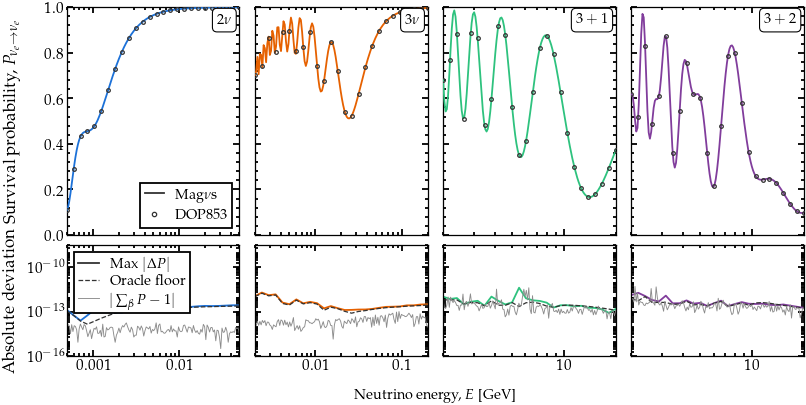

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(WIDE, 3.25), sharex='col',
                         gridspec_kw=dict(height_ratios=[2.05, 1.0], hspace=0.06,
                                          wspace=0.09))
COLORS = {2: BLUE, 3: ORANGE, 4: GREEN, 5: PURPLE}
for j, d in enumerate((2, 3, 4, 5)):
    r = results[d]
    top, bot = axes[0, j], axes[1, j]
    x = r['E_plot']/gd.UNIT_GEV
    top.plot(x, r['P_plot'][:, 0, 0], color=COLORS[d], lw=1.0, zorder=3)
    top.plot(r['E_ref']/gd.UNIT_GEV, r['Pr'][:, 0, 0], ls='none', marker='o', ms=2.0,
             mfc='none', mew=0.7, color=INK, zorder=4)
    logx(top); snug(top, x); top.set_ylim(0.0, 1.0); minor_y(top, 5)
    corner(top, FLAVOR_LABEL[d], fontsize=8.0, x=0.955, y=0.975)
    bot.semilogy(r['E_ref']/gd.UNIT_GEV, np.maximum(r['resid'], 1.0e-18),
                 color=COLORS[d], lw=1.0)
    bot.semilogy(r['E_ref']/gd.UNIT_GEV, np.maximum(r['floor'], 1.0e-18), color=INK,
                 lw=0.7, ls='--')
    bot.semilogy(x, np.maximum(r['unit'], 1.0e-18), color='0.55', lw=0.5)
    logx(bot); logy(bot); snug(bot, x); bot.set_ylim(1.0e-16, 3.0e-9)
    if j:
        top.tick_params(labelleft=False)
        bot.tick_params(labelleft=False)
axes[0, 0].set_ylabel(r'Survival probability, $P_{\nu_e \to \nu_e}$')
axes[1, 0].set_ylabel(r'Absolute deviation')
axes[0, 0].plot([], [], color=INK, lw=1.0, label=r'Mag$\nu$s')
axes[0, 0].plot([], [], ls='none', marker='o', ms=2.4, mfc='none', mew=0.7, color=INK,
                label='DOP853')
axes[0, 0].legend(loc='lower right', handlelength=1.3)
axes[1, 0].plot([], [], color=INK, lw=1.0, label=r'Max $|\Delta P|$')
axes[1, 0].plot([], [], color=INK, lw=0.7, ls='--', label='Oracle floor')
axes[1, 0].plot([], [], color='0.55', lw=0.5, label=r'$|\sum_\beta P - 1|$')
axes[1, 0].legend(loc='upper left', handlelength=1.4, labelspacing=0.18, fontsize=8.0)
# Centred on the four columns rather than on the figure, which the y-axis label
# would otherwise pull left, and close to the axis it belongs to.
fig.align_labels()
box = [axes[1, j].get_position() for j in range(4)]
fig.text(0.5*(box[0].x0 + box[3].x1), box[0].y0 - 0.075,
         r'Neutrino energy, $E$ [GeV]', ha='center', va='top', fontsize=8)
save(fig, 'validation.pdf')

### Figure 1b --- how a call is answered

Six engines can answer a request, tried in a fixed order; each declines what it cannot
serve honestly and falls through to the next.

  wrote /home/mbustamante/Research/magnus/resources/paper/figs/strategies.pdf


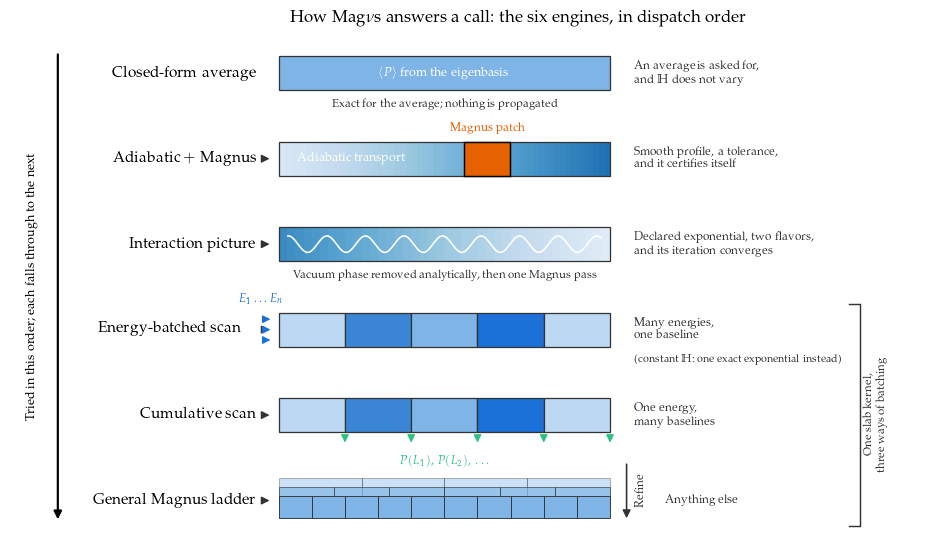

In [5]:
# ------------------------------------------- Figure 1b: the six engines, in order
# Same idiom as the slab-composition figure of the companion paper: one bar per
# engine, shaded by density, with what each does to the trajectory drawn rather
# than named.  The order is the dispatch order of the three scenario wrappers.
SLAB = ['#eaf2fb', '#bcd8f3', '#7fb4e6', '#3a86d4', '#1c71d8']
from matplotlib.patches import Rectangle
fig, ax = plt.subplots(figsize=(WIDE, 4.3))
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis('off')
X0, X1 = 30.0, 66.0                      # the bar spans the same x in every row
H = 6.2                                  # bar height
rows = [
 ('Closed-form average',   'An average is asked for,\nand $\\mathbb{H}$ does not vary'),
 ('Adiabatic $+$ Magnus',  'Smooth profile, a tolerance,\nand it certifies itself'),
 ('Interaction picture',   'Declared exponential, two flavors,\nand its iteration converges'),
 ('Energy-batched scan',   'Many energies,\none baseline'),
 ('Cumulative scan',       'One energy,\nmany baselines'),
 ('General Magnus ladder', 'Anything else'),
]
ys = np.linspace(84, 6, len(rows))

def bar(y, edges, shades, lw=0.7):
    for (a, b), c in zip(edges, shades):
        ax.add_patch(Rectangle((a, y), b-a, H, facecolor=c, edgecolor=INK, lw=lw, zorder=2))

for i, ((name, when), y) in enumerate(zip(rows, ys)):
    # The energy-batched row has arrows entering at its left edge, so its name needs
    # more clearance than the others.
    ax.text(X0-(4.2 if i == 3 else 2.5), y+H/2, name, ha='right', va='center',
            fontsize=8.6, color='black')
    # The ladder row carries the refine arrow just past its bar, so its condition
    # text starts further right than the others'.
    ax.text(X1+(6.0 if i == 5 else 2.6), y+H/2, when, ha='left', va='center',
            fontsize=6.6, color=INK)
    if i:                                        # every engine but the first walks a path
        ax.annotate('', xy=(X0-0.6, y+H/2), xytext=(X0-1.8, y+H/2),
                    arrowprops=dict(arrowstyle='-|>', color=INK, lw=0.8))
    if i == 0:
        # One undivided block: nothing is composed along it, because nothing is
        # propagated.  avgprob diagonalises H once and sums |sum_i V*_ai V_bi|^2 over
        # the eigenbasis, which is exact for the averaged observable -- not a closed
        # form in the mixing parameters, since it still needs the eigenvectors.
        bar(y, [(X0, X1)], [SLAB[2]])
        ax.text((X0+X1)/2, y+H/2, r'$\langle P\rangle$ from the eigenbasis',
                ha='center', va='center', fontsize=7.0, color='white')
        ax.text((X0+X1)/2, y-1.6, 'Exact for the average; nothing is propagated',
                ha='center', va='top', fontsize=6.4, color=INK)
    elif i == 1:                                 # smooth gradient, one exact patch
        n = 60; e = np.linspace(X0, X1, n+1)
        g = plt.cm.Blues(np.linspace(0.15, 0.75, n))
        bar(y, list(zip(e[:-1], e[1:])), g, lw=0.0)
        ax.add_patch(Rectangle((X0, y), X1-X0, H, fill=False, edgecolor=INK, lw=0.7, zorder=3))
        px = X0 + 0.56*(X1-X0)
        ax.add_patch(Rectangle((px, y), 5.0, H, facecolor=ORANGE, edgecolor='black',
                               lw=0.8, zorder=4))
        ax.text(px+2.5, y+H+1.4, 'Magnus patch', ha='center', va='bottom',
                fontsize=6.6, color=ORANGE)
        ax.text(X0+0.22*(X1-X0), y+H/2, 'Adiabatic transport', ha='center', va='center',
                fontsize=7.0, color='white', zorder=5)
    elif i == 2:                                 # fast phase factored out first
        n = 40; e = np.linspace(X0, X1, n+1)
        g = plt.cm.Blues(np.linspace(0.65, 0.12, n))
        bar(y, list(zip(e[:-1], e[1:])), g, lw=0.0)
        ax.add_patch(Rectangle((X0, y), X1-X0, H, fill=False, edgecolor=INK, lw=0.7, zorder=3))
        xs = np.linspace(X0+1, X1-1, 300)
        ax.plot(xs, y+H/2 + 1.5*np.sin((xs-X0)*1.5), color='white', lw=0.9, zorder=5)
        ax.text((X0+X1)/2, y-1.6, r'Vacuum phase removed analytically, then one Magnus pass',
                ha='center', va='top', fontsize=6.4, color=INK)
    elif i == 3:                                 # profile once, many energies
        ed = np.linspace(X0, X1, 6)
        bar(y, list(zip(ed[:-1], ed[1:])), [SLAB[1], SLAB[3], SLAB[2], SLAB[4], SLAB[1]])
        for dy in (1.9, 0.0, -1.9):
            ax.annotate('', xy=(X0-0.5, y+H/2+dy), xytext=(X0-2.1, y+H/2+dy),
                        arrowprops=dict(arrowstyle='-|>', color=BLUE, lw=0.7))
        ax.text(X0-2.0, y+H+1.2, r'$E_1 \ldots E_n$', ha='center', va='bottom',
                fontsize=6.6, color=BLUE)
    elif i == 4:                                 # one pass, many baselines out
        ed = np.linspace(X0, X1, 6)
        bar(y, list(zip(ed[:-1], ed[1:])), [SLAB[1], SLAB[3], SLAB[2], SLAB[4], SLAB[1]])
        for xx in ed[1:]:
            ax.annotate('', xy=(xx, y-2.6), xytext=(xx, y+0.2),
                        arrowprops=dict(arrowstyle='-|>', color=GREEN, lw=0.7))
        ax.text((X0+X1)/2, y-4.2, r'$P(L_1),\, P(L_2),\, \ldots$', ha='center', va='top',
                fontsize=6.6, color=GREEN)
    else:                                        # the ladder: refine until two levels agree
        for tier, (nsl, dy, al) in enumerate([(4, 3.4, 0.40), (6, 1.7, 0.68), (10, 0.0, 1.0)]):
            ed = np.linspace(X0, X1, nsl+1)
            for a, b in zip(ed[:-1], ed[1:]):
                ax.add_patch(Rectangle((a, y+dy), b-a, H*0.62, facecolor=SLAB[2],
                                       edgecolor=INK, lw=0.5, alpha=al, zorder=2))
        ax.annotate('', xy=(X1+1.8, y-0.8), xytext=(X1+1.8, y+H+4.2),
                    arrowprops=dict(arrowstyle='-|>', color=INK, lw=0.9))
        ax.text(X1+3.4, y+H/2+1.7, 'Refine', ha='center', va='center', fontsize=6.6,
                color=INK, rotation=90)

ax.text(56.0, 97.0, r'How Mag$\nu$s answers a call: the six engines, in dispatch order',
        ha='center', va='center', fontsize=9.4, color='black')

# The order they are tried in, drawn once in the margin: down the middle it crossed
# every bar and collided with the notes under rows 1, 3 and 5.
ax.annotate('', xy=(6.0, ys[-1]-1.0), xytext=(6.0, ys[0]+H+1.0),
            arrowprops=dict(arrowstyle='-|>', color='black', lw=1.2))
ax.text(3.2, (ys[0]+ys[-1])/2 + H/2, 'Tried in this order; each falls through to the next',
        rotation=90, ha='center', va='center', fontsize=7.0, color='black')

# The last three share one kernel, which is what decides whether a disagreement between
# two of them means anything.  The energy-batched row is the exception noted beside it:
# a potential that does not vary is served by a single exact exponential instead.
gy0, gy1 = ys[5] - 1.6, ys[3] + H + 1.6
gx = 92.0
ax.plot([gx, gx+1.2, gx+1.2, gx], [gy0, gy0, gy1, gy1], color=INK, lw=0.8,
        solid_joinstyle='miter')
ax.text(gx + 2.8, (gy0 + gy1)/2, 'One slab kernel,\nthree ways of batching', rotation=90,
        ha='center', va='center', fontsize=6.4, color=INK)
ax.text(X1+2.6, ys[3]-1.4, r'(constant $\mathbb{H}$: one exact exponential instead)',
        ha='left', va='top', fontsize=6.0, color=INK, style='italic')
fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.01)
save(fig, 'strategies.pdf')

## Figure 1c --- how the modules fit together

  wrote /home/mbustamante/Research/magnus/resources/paper/figs/architecture.pdf


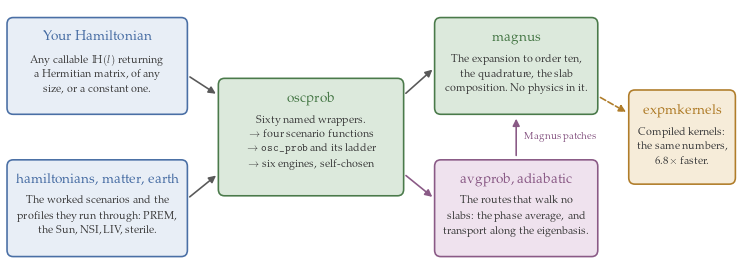

In [6]:
# ------------------------------------------- Figure 1c: the module architecture
# Same idiom, and deliberately the same style, as the architecture figure of the
# companion paper: the four colour pairs, the box geometry, and the title and body
# both set from the top of the box so that no box carries dead space at its foot.
from matplotlib.patches import FancyBboxPatch

C_IN, C_CORE, C_ACC, C_COMP = '#e8eef6', '#dce9dc', '#f6ecd9', '#efe2ee'
E_IN, E_CORE, E_ACC, E_COMP = '#4a6fa5', '#4a7a4a', '#b07d2a', '#8a5a86'

fig, axd = plt.subplots(figsize=(WIDE, WIDE*0.34))
axd.set_axis_off(); axd.set_xlim(0.0, 30.0); axd.set_ylim(0.0, 10.2)


def _abox(x, y, w, h, face, edge, title, body):
    axd.add_patch(FancyBboxPatch((x, y), w, h,
                                 boxstyle='round,pad=0.12,rounding_size=0.25',
                                 facecolor=face, edgecolor=edge, lw=0.9, zorder=2))
    axd.text(x + w/2.0, y + h - 0.42, title, ha='center', va='top', fontsize=7.6,
             color=edge, zorder=3,
             fontfamily='monospace' if title[0].islower() else None)
    if body:
        axd.text(x + w/2.0, y + h - 1.30, body, ha='center', va='top', fontsize=6.0,
                 color='0.25', zorder=3, linespacing=1.5)


def _aarr(x0, y0, x1, y1, color='0.35', ls='-'):
    axd.annotate('', xy=(x1, y1), xytext=(x0, y0), zorder=1,
                 arrowprops=dict(arrowstyle='-|>', mutation_scale=8, lw=0.9,
                                 color=color, linestyle=ls, shrinkA=2, shrinkB=2))


# Left: what goes in.  Middle: where a request is met.  Right: the three routes out.
_abox(0.3, 6.00, 7.1, 3.50, C_IN, E_IN, 'Your Hamiltonian',
      'Any callable $\\mathbb{H}(l)$ returning\na Hermitian matrix, of any\nsize, or a constant one.')
_abox(0.3, 0.50, 7.1, 3.50, C_IN, E_IN, 'hamiltonians, matter, earth',
      'The worked scenarios and the\nprofiles they run through: PREM,\nthe Sun, NSI, LIV, sterile.')
_abox(8.9, 2.85, 7.3, 4.30, C_CORE, E_CORE, 'oscprob',
      'Sixty named wrappers.\n$\\rightarrow$ four scenario functions\n'
      '$\\rightarrow$ {\\tt osc\\_prob} and its ladder\n$\\rightarrow$ six engines, self-chosen')
_abox(17.7, 6.00, 6.4, 3.50, C_CORE, E_CORE, 'magnus',
      'The expansion to order ten,\nthe quadrature, the slab\ncomposition. No physics in it.')
_abox(17.7, 0.50, 6.4, 3.50, C_COMP, E_COMP, 'avgprob, adiabatic',
      'The routes that walk no\nslabs: the phase average, and\ntransport along the eigenbasis.')
_abox(25.6, 3.30, 4.1, 3.40, C_ACC, E_ACC, 'expmkernels',
      'Compiled kernels:\nthe same numbers,\n$6.8{\\times}$ faster.')

_aarr(7.5, 7.4, 8.8, 6.6)
_aarr(7.5, 2.6, 8.8, 3.6)
_aarr(16.3, 6.6, 17.6, 7.7)
_aarr(16.3, 3.6, 17.6, 2.6, color=E_COMP)
_aarr(20.9, 4.15, 20.9, 5.85, color=E_COMP)
_aarr(24.2, 6.6, 25.5, 5.9, color=E_ACC, ls='--')
axd.text(21.2, 5.00, 'Magnus patches', ha='left', va='center', fontsize=5.6, color=E_COMP)
save(fig, 'architecture.pdf')

## Figure 2 --- slab width follows the profile, not the phase

Three measurements: one slab against a constant Hamiltonian over six decades of $\Phi$;
the cost of a *delivered* accuracy as $\Phi$ grows; and what the truncation order buys at
fixed $\Phi$.

**All three panels are measured against the same reference**: a midpoint slab product
carried in `mpmath` and Richardson-extrapolated three times, with its own convergence
reported so that no panel has to be taken on trust. `DOP853` appears in the center panel
as the code being timed, never as a reference. For a constant Hamiltonian the
extrapolation collapses to a single exponential, which the left panel checks rather than
assumes.

In [7]:
# ============================================================ Figure 2
D2 = 3
RHO0_2, LS_KM_2, RHO_CONST = 100.0, 300.0, 3.0
rho2 = matter.exp_density_profile(RHO0_2*gd.UNIT_G_PER_CM3, LS_KM_2*gd.UNIT_KM)
VCC2 = matter.vcc_func_from_rho_func(rho2, L0=0.0)
L2 = 3000.0*gd.UNIT_KM
E_FIX = 0.2*gd.UNIT_GEV
Hf2 = make_H_func(D2, E_FIX, VCC2)

# The six configurations both lower panels carry: what an order buys, beside what it costs.
# Orders two, four and six run on the commutator-free Gauss-Legendre schemes, which is what
# the package does by default.  Above six no such scheme exists, so the only route is
# cumulative quadrature; order six is run on it too, as a control, because the change in
# convergence rate belongs to the quadrature path and not to the higher orders.
SERIES = [('gl', 2), ('gl', 4), ('gl', 6), ('simpson', 6), ('simpson', 8), ('simpson', 10)]

MP_DPS_FIX, MP_NS_FIX = 50, (4096, 8192, 16384, 32768)
MP_DPS_SCAN, MP_SCAN_TARGET = 30, 1.0e-11
def slab_product(H_func, L, n_slabs):
    """The piecewise-constant operator, H frozen at each slab midpoint.

    The algorithm a closed-form slab code runs, written out here so that this
    comparison needs no second package installed.  The midpoint rather than the edge
    is what makes it second order: the linear part of the error cancels between a
    slab's two halves.
    """
    edges = np.linspace(0.0, L, n_slabs + 1)
    Hs = H_func(0.5*(edges[:-1] + edges[1:]))
    h = edges[1] - edges[0]
    U = np.eye(Hs.shape[-1], dtype=complex)
    for k in range(n_slabs):
        U = expm(-1j*Hs[k]*h) @ U
    return prob_from_U(U)


def chunked_prob(H_func, L, n_slabs, order, integration_method='gl', n_tpts=65,
                 max_cells=20000):
    """The package's slab chain, composed a batch at a time.

    Orders above six have no Gauss-Legendre scheme and run on cumulative quadrature,
    which carries ``n_tpts`` samples per slab.  At order ten the recursion holds of
    order a hundred intermediates of shape ``(n_slabs, n_tpts, d, d)``, about 6 MB per
    slab, and exhausts memory past roughly a thousand slabs.  Composition is a product
    of independent per-slab operators, so the chain can be built in chunks and
    multiplied in, which holds memory flat in ``n_slabs``.  The cell below checks this
    against ``osc_prob`` at every order.
    """
    edges = np.linspace(0.0, L, n_slabs + 1)
    nodes = (magnus.gl_nodes(order) if integration_method == 'gl'
             else np.linspace(0.0, 1.0, n_tpts))
    m = len(nodes)
    d = np.asarray(H_func(0.0)).shape[-1]
    chunk = max(1, min(n_slabs, int(max_cells//m)))
    U = np.eye(d, dtype=complex)
    for a in range(0, n_slabs, chunk):
        b = min(a + chunk, n_slabs)
        lo, hi = edges[a:b], edges[a + 1:b + 1]
        t = lo[:, None] + (hi - lo)[:, None]*nodes[None, :]
        At = -1j*np.asarray(H_func(t.ravel()), dtype=complex).reshape(b - a, m, d, d)
        Us = quiet(magnus.evolution_operators_from_samples, At, hi - lo, order=order,
                   integration_method=integration_method, validate_input=False)
        for k in range(b - a):
            U = Us[k] @ U
    return prob_from_U(U)


def mp_midpoint(H_func, L, n, dps):
    r"""A midpoint slab product carried at ``dps`` decimal digits, in mpmath.

    The panels below have to resolve deviations near $10^{-15}$, which no
    double-precision reference can certify.  A {\tt DOP853} solution moves by
    $2 \cdot 10^{-13}$ between ${\tt rtol} = 10^{-13}$ and $10^{-14}$, and a
    double-precision {\tt expm} of a constant Hamiltonian is itself wrong by
    $2 \cdot 10^{-10}$ at the largest phase the left panel reaches.  The probabilities
    come back as {\tt mpf} rather than as {\tt float}, since rounding them to double at
    this point would put a floor of $10^{-16}$ under everything built from them.
    """
    mp.mp.dps = dps
    edges = np.linspace(0.0, L, n + 1)
    Hs = H_func(0.5*(edges[:-1] + edges[1:]))
    h = mp.mpf(float(edges[1] - edges[0]))
    d = Hs.shape[-1]
    U = mp.eye(d)
    for k in range(n):
        M = mp.matrix([[mp.mpc(complex(Hs[k][i, j])) for j in range(d)] for i in range(d)])
        U = mp.expm(-1j*M*h)*U
    P = np.array([[mp.fabs(U[i, j])**2 for j in range(d)] for i in range(d)], dtype=object)
    return P.T


def richardson3(P, ns):
    r"""Remove $N^{-2}$, $N^{-4}$ and $N^{-6}$ in turn, staying in mpmath throughout.

    The midpoint product's error runs in even powers of the slab width, so
    $[4P(2N) - P(N)]/3$ removes the leading term, $[16Q(2N) - Q(N)]/15$ the next and
    $[64R(2N) - R(N)]/63$ the one after.  An earlier version returned {\tt float}
    probabilities from each product and combined them in double precision; it converged
    to $1.1 \cdot 10^{-16}$, which is double-precision epsilon and not the
    extrapolation.  Returns the reference together with its own self-convergence, so no
    panel has to take the reference on trust.
    """
    Q = {n: (4*P[2*n] - P[n])/3 for n in ns[:-1]}
    R = {n: (16*Q[2*n] - Q[n])/15 for n in ns[:-2]}
    T = (64*R[ns[1]] - R[ns[0]])/63
    return T, float(max(abs(x) for x in (T - R[ns[1]]).ravel()))


def mp_reference(H_func, L, base, dps=MP_DPS_SCAN, target=MP_SCAN_TARGET, cap=2048):
    r"""Triple-Richardson reference, with the base slab count raised until it converges.

    The base a trajectory needs grows with the accumulated phase: nine hundred radians
    needs $512$ where eight radians needs $64$.  Doubling until the self-convergence
    clears ``target`` finds it rather than assuming it.
    """
    while True:
        ns = (base, 2*base, 4*base, 8*base)
        T, sc = richardson3({n: mp_midpoint(H_func, L, n, dps) for n in ns}, ns)
        if sc < target or base >= cap:
            return T, sc, base
        base *= 2




# One reference machinery serves all three panels.  For a constant Hamiltonian every
# midpoint slab product is the same exponential whatever N, so the triple Richardson of
# them collapses to that one exponential; the print below measures the collapse rather
# than assuming it.  This matters: the double-precision expm this panel used to be
# measured against is itself wrong by 2e-10 at the largest phase here, so the old curve
# was as much the reference's round-off as the method's.
VCC_CONST = float(matter.vcc_func_from_rho_func(RHO_CONST*gd.UNIT_G_PER_CM3))
E_CONST = np.logspace(np.log10(50.0), np.log10(5.0e-6), 60)*gd.UNIT_GEV
PROJ2 = np.asarray(matter.matter_potential_projector(D2), dtype=complex)
HVAC2 = np.asarray(vacuum_hamiltonian(D2), dtype=complex)


def const_H_func(Hc):
    def f(l):
        return np.broadcast_to(Hc, np.shape(l) + Hc.shape).copy()
    return f


phase_a, err_a, collapse = [], [], []
for E in E_CONST:
    Hc = HVAC2/E + VCC_CONST*PROJ2
    w = np.linalg.eigvalsh(Hc)
    phase_a.append(float((w[-1] - w[0])*L2))
    Hcf = const_H_func(Hc)
    T, sc, _ = mp_reference(Hcf, L2, 4, dps=MP_DPS_FIX, target=1.0e-40)
    collapse.append(float(max(abs(x) for x in (T - mp_midpoint(Hcf, L2, 1, MP_DPS_FIX)).ravel())))
    P1 = np.asarray(quiet(oscprob.osc_prob, lambda l, H=Hc: H, 0.0, L2, n_slabs=1,
                          rtol=None, atol=None))
    err_a.append(max(float(max(abs(x) for x in (P1 - T).ravel())), 1.0e-18))
phase_a, err_a = np.array(phase_a), np.array(err_a)
print('left panel: %d points, phase %.1e to %.1e rad' % (len(phase_a), phase_a.min(), phase_a.max()))
print('  triple Richardson vs one exponential, constant H: %.1e' % max(collapse))
print('  deviation of one slab: %.1e to %.1e, growing as Phi^%.2f'
      % (err_a.min(), err_a.max(),
         np.polyfit(np.log(phase_a[phase_a > 1e2]), np.log(err_a[phase_a > 1e2]), 1)[0]))
print('  for comparison, Phi*eps at the largest phase is %.1e' % (phase_a.max()*2.220446e-16))

left panel: 60 points, phase 1.7e+00 to 3.8e+06 rad
  triple Richardson vs one exponential, constant H: 6.1e-50
  deviation of one slab: 1.3e-16 to 6.2e-10, growing as Phi^0.98
  for comparison, Phi*eps at the largest phase is 8.5e-10


### The center panel --- cost at an accuracy each code actually delivers

In [8]:
# --------------------------- Figure 2, cost panel: price at one fixed, tight tolerance
# Every configuration is run at one tolerance, fixed before the sweep starts and never
# retuned -- the solver included, so that nothing is asked for less than anything else.
# Searching per energy for the cheapest setting that just clears an accuracy target was
# what made this panel jagged: the ladders are discrete, so neighbouring energies landed
# on different rungs and the cost jumped between them for no reason a reader could see.
# It is also not how the code is used.  A tolerance is chosen once and the energies are
# swept under it, so that is what the panel measures.
#
# A tolerance is a request, not a guarantee, so what each configuration DELIVERS at it is
# measured rather than assumed, and the spread is reported with the figure.
RTOL_FIXED = 1.0e-8
ENERGIES2 = np.logspace(np.log10(20.0), np.log10(0.02), 41)


# Order two converges as N^-2, so it refines to 106204 slabs at the highest phase swept
# here -- five times the 20000 the Gauss-Legendre path caps at by default, which would
# have truncated it silently.  The ceiling is raised for every Gauss-Legendre
# configuration rather than for order two alone, so that none of them is capped where the
# others are not, and the cost each is charged is the cost of the work it actually did.
GL_SLAB_CEILING = 400000


def magnus_call(Hf, order, meth, n_tpts):
    kw = dict(magnus_exp_order=order, integration_method=meth)
    if meth == 'gl':
        kw.update(max_n_slabs=GL_SLAB_CEILING, max_num_loops=80)
    elif n_tpts is not None:
        kw.update(n_tpts_per_slab=n_tpts, min_n_tpts_per_slab=n_tpts,
                  max_n_tpts_per_slab=n_tpts)
    return lambda rt: np.asarray(quiet(oscprob.osc_prob, Hf, 0.0, L2, rtol=rt,
                                       atol=rt*1e-2, **kw))


def dop853_call(Hf):
    return lambda rt: ode_reference(Hf, L2, D2, rtol=rt, atol=rt*1e-2)


# One entry per curve.  The panel carries the same six configurations as the panel beside
# it, so that what an order costs can be read against what it buys, together with the
# solver they are all measured against.
CODES = [('dop853', 'Ref.: Runge-Kutta order 8 (DOP853)', INK, '-', None, None)]
for _meth, _order in SERIES:
    CODES.append(('%s%d' % (_meth, _order),
                  '%d, %s' % (_order, 'GL' if _meth == 'gl' else 'Simpson'),
                  ORDER_COLOR[_order], '-' if _meth == 'gl' else '--', _meth, _order))


def fixed_setting(name, meth):
    """The single setting this configuration is run at, at every energy.

    A tolerance and nothing else.  Pinning the samples per slab for the cumulative-
    quadrature configurations would hold their delivered accuracies closer together, but
    it is a setting no caller types: the package refines that knob from the tolerance
    along with the slab count, and whatever it costs to do so is part of what the call
    costs.  The panel beside this one pins it, on purpose --- there the slab count is the
    variable under study, so the quadrature has to be held out of the way.
    """
    return {'rtol': RTOL_FIXED}


def call_for(name, meth, order, Hf, setting):
    return (dop853_call(Hf) if name == 'dop853'
            else magnus_call(Hf, order, meth, setting.get('n_tpts')))


def delivered(call, rt, T):
    return float(max(abs(x) for x in (np.asarray(call(rt)) - T).ravel()))


def measure_once(name, meth, order, Hf, rt, T):
    """One call, read twice: what it delivers, and what its ladder settled on.

    Asking those separately would run the whole configuration twice at identical settings
    --- order ten unpinned is not cheap enough to pay for that.
    """
    if name == 'dop853':
        P = np.asarray(dop853_call(Hf)(rt))
        return float(max(abs(x) for x in (P - T).ravel())), {}
    info = {}
    kw = dict(magnus_exp_order=order, integration_method=meth, convergence_info=info)
    if meth == 'gl':
        kw.update(max_n_slabs=GL_SLAB_CEILING, max_num_loops=80)
    P = np.asarray(quiet(oscprob.osc_prob, Hf, 0.0, L2, rtol=rt, atol=rt*1e-2, **kw))
    return (float(max(abs(x) for x in (P - T).ravel())),
            {k: int(info[k]) for k in ('n_slabs', 'n_tpts_per_slab') if k in info})


def scan_setup():
    """Reference and tuned setting at each energy, computed once and read from disk after.

    Five minutes of mpmath and a two-knob search that runs order ten at its tightest
    settings are worth spending once rather than on every rebuild.  Both are properties of
    the configuration and not of the machine, so both are cached; only the timings below
    have to be measured live.  The cached settings are re-verified rather than trusted ---
    one call per configuration per energy --- so a change in the package that moved them
    cannot pass silently.
    """
    key = fingerprint(profile_samples(VCC2, L2), float(L2), D2, MP_DPS_SCAN, MP_SCAN_TARGET,
                      [c[0] for c in CODES],
                      [float(e) for e in ENERGIES2], RTOL_FIXED, 'fixed-tolerance')
    blob = json.loads(MP_CACHE.read_text()) if MP_CACHE.exists() else {}
    cached = blob.get('scan', {})
    entries = cached.get('entries') if cached.get('fingerprint') == key else None
    if entries is not None:
        mp.mp.dps = MP_DPS_SCAN
        Ts = [np.array([[mp.mpf(x) for x in row] for row in e['P']], dtype=object)
              for e in entries]
        # Spot-checked rather than fully re-run: the fingerprint already covers the
        # configuration, so this is here to catch a change inside the package that moved
        # the answers under an unchanged configuration.  Three energies at the ends and
        # the middle of the sweep do that; forty-one would cost minutes on every
        # regeneration to re-derive what the fingerprint already settled.
        # Once per package version, not once per regeneration.  The fingerprint already
        # covers the configuration; what it cannot see is a change inside the package
        # that moves the answers under a configuration that did not move.  Tying the
        # check to the version catches exactly that, and costs nothing on the format
        # edits that make up most rebuilds.  A cache written before this field existed
        # is adopted rather than re-probed: the code that wrote it was this code.
        seen_version = cached.get('magnus_version')
        if seen_version == MAGNUS_VERSION or seen_version is None:
            if seen_version is None:
                blob['scan'] = dict(cached, magnus_version=MAGNUS_VERSION)
                write_cache(blob)
            print('  references and delivered accuracies read from %s, configuration %s'
                  % (MP_CACHE.name, key[:12]))
            return Ts, entries
        print('  package moved from %s to %s: spot-checking the stored accuracies'
              % (seen_version, MAGNUS_VERSION))
        probe = sorted({0, len(entries)//2, len(entries) - 1})
        stale = []
        for i in probe:
            e, T = entries[i], Ts[i]
            Hf = make_H_func(D2, e['E']*gd.UNIT_GEV, VCC2)
            for name, _, _, _, meth, order in CODES:
                st = e['setting'][name]
                now = delivered(call_for(name, meth, order, Hf, st), st['rtol'], T)
                if not (0.5 <= now/max(e['acc'][name], 1.0e-18) <= 2.0):
                    stale.append((e['E'], name, e['acc'][name], now))
        if not stale:
            blob['scan'] = dict(cached, magnus_version=MAGNUS_VERSION)
            write_cache(blob)
            print('  stored accuracies still hold under %s, re-verified at %d energies'
                  % (MAGNUS_VERSION, len(probe)))
            return Ts, entries
        print('  the package now delivers differently at %d spot checks '
              '(e.g. %s at %.3f GeV: %.1e stored, %.1e now): recomputing'
              % (len(stale), stale[0][1], stale[0][0], stale[0][2], stale[0][3]))
    else:
        cache_miss('scan', key)
    print('  energy scan: configuration moved, recomputing')
    t0 = time.perf_counter()
    Ts, entries = [], []
    for Egev in ENERGIES2:
        Hf = make_H_func(D2, Egev*gd.UNIT_GEV, VCC2)
        T, sc, base = mp_reference(Hf, L2, 32)
        setting = {name: fixed_setting(name, meth)
                   for name, _, _, _, meth, _ in CODES}
        got = {name: measure_once(name, meth, order, Hf, setting[name]['rtol'], T)
               for name, _, _, _, meth, order in CODES}
        acc = {k: v[0] for k, v in got.items()}
        chose = {k: v[1] for k, v in got.items()}
        Ts.append(T)
        entries.append(dict(E=float(Egev), phase=accumulated_phase(Hf, L2), base=int(base),
                            self_conv=float(sc), setting=setting, acc=acc, chose=chose,
                            P=[[mp.nstr(x, MP_DPS_SCAN - 5) for x in row] for row in T]))
        print('    %6.3f GeV done, worst delivered %.1e (%.0f s elapsed)'
              % (Egev, max(acc.values()), time.perf_counter() - t0), flush=True)
    print('  %d references in %.0f s, worst self-convergence %.1e'
          % (len(Ts), time.perf_counter() - t0, max(e['self_conv'] for e in entries)))
    blob['scan'] = dict(dps=MP_DPS_SCAN, target=MP_SCAN_TARGET, rtol=RTOL_FIXED,
                        fingerprint=key, entries=entries)
    write_cache(blob)
    return Ts, entries


REFS2, REF_INFO2 = scan_setup()
print('at rtol = %.0e, over %d energies:' % (RTOL_FIXED, len(REF_INFO2)))
for _n, _lab, _, _, _, _ in CODES:
    _a = [e['acc'][_n] for e in REF_INFO2]
    _c = [e.get('chose', {}).get(_n, {}) for e in REF_INFO2]
    _ns = [d['n_slabs'] for d in _c if 'n_slabs' in d]
    _nt = [d['n_tpts_per_slab'] for d in _c if 'n_tpts_per_slab' in d]
    print('  %-30s delivered %.1e to %.1e%s%s'
          % (_lab, min(_a), max(_a),
             '' if not _ns else ',  %d-%d slabs' % (min(_ns), max(_ns)),
             '' if not _nt else ',  %d-%d samples/slab' % (min(_nt), max(_nt))))


def best_of(fn, k=5):
    out = []
    for _ in range(k):
        t0 = time.perf_counter()
        fn()
        out.append(time.perf_counter() - t0)
    return min(out)


# A fixed workload interleaved through the sweep, so machine drift is visible rather than
# absorbed into the curves.
H_CTRL = make_H_func(D2, 1.0*gd.UNIT_GEV, VCC2)
_CTRL0 = []


def control_baseline():
    """The control's first value, measured on demand.

    At cell scope this ran a warm-up and five timed repeats on every regeneration of the
    notebook, including the ones that only moved a label.  It is an input to the timings
    and to nothing else, so it belongs behind the same cache they do.
    """
    if not _CTRL0:
        quiet(oscprob.osc_prob, H_CTRL, 0.0, L2, rtol=1e-8, atol=1e-10)  # warm numba
        _CTRL0.append(best_of(lambda: quiet(oscprob.osc_prob, H_CTRL, 0.0, L2,
                                            rtol=1e-8, atol=1e-10)))
    return _CTRL0[0]

def measure_timings():
    """Time each configuration at its tuned setting, once, and read from disk after.

    Timing is the only part of this figure that is a property of the machine rather than
    of the configuration, which is the argument for measuring it live.  It is also minutes
    of work on every rebuild, and the notebooks are regenerated in continuous integration,
    where minutes of stopwatch tell nobody anything.  So it is cached like everything else,
    keyed on the configuration alone: change an energy, a code, a tolerance target or a
    tuned setting and it is re-measured; change nothing and the stored numbers stand.

    The machine and the date are stored beside the numbers, because a timing that does not
    say where it came from cannot be checked.  Set MAGNUS_PAPER_RETIME=1 to force a fresh
    measurement without changing the configuration -- which is what to do after moving the
    paper to another machine.
    """
    key = fingerprint(profile_samples(VCC2, L2), float(L2), D2, RTOL_FIXED, [c[0] for c in CODES],
                      [float(e['E']) for e in REF_INFO2],
                      [repr(e['setting']) for e in REF_INFO2])
    blob = json.loads(MP_CACHE.read_text()) if MP_CACHE.exists() else {}
    stored = blob.get('timings', {})
    if stored.get('fingerprint') == key and not os.environ.get('MAGNUS_PAPER_RETIME'):
        print('  timings read from %s, unchanged configuration %s, measured on %s'
              % (MP_CACHE.name, key[:12], stored.get('machine', 'an unrecorded machine')))
        return stored['rows']
    cache_miss('timings', key)
    print('  timings: configuration moved, re-measuring')
    out = []
    for e in REF_INFO2:
        Hf = make_H_func(D2, e['E']*gd.UNIT_GEV, VCC2)
        # The control is measured beside the point, not once at the start, and divided
        # out.  A sweep of forty-one energies takes long enough that the machine drifts
        # under it, and drift that is not divided out is read off the panel as structure.
        ctrl = best_of(lambda: quiet(oscprob.osc_prob, H_CTRL, 0.0, L2,
                                     rtol=1e-8, atol=1e-10), 5)
        drift = ctrl/control_baseline()
        t = {}
        for name, _, _, _, meth, order in CODES:
            st = e['setting'][name]
            call, rt = call_for(name, meth, order, Hf, st), st['rtol']
            t[name] = best_of(lambda c=call, x=rt: c(x), 5)/drift
        out.append(dict(phase=e['phase'], E=e['E'], t=t, acc=e['acc'], ctrl=drift))
    blob['timings'] = dict(fingerprint=key, rows=out,
                           machine=platform.node() + ', ' + platform.processor(),
                           measured=time.strftime('%Y-%m-%d'))
    write_cache(blob)
    return out


rows = measure_timings()
ph = np.array([r['phase'] for r in rows])
times = {name: np.array([r['t'][name] for r in rows]) for name, _, _, _, _, _ in CODES}
print('cost panel: %d points, phase %.1f to %.0f rad' % (len(rows), ph.min(), ph.max()))
for name, lab, _, _, _, _ in CODES:
    tt = times[name]
    print('  %-28s phase^%5.2f  %7.2f ms to %8.1f ms   worst delivered %.1e'
          % (lab, np.polyfit(np.log(ph), np.log(tt), 1)[0], 1e3*tt[0], 1e3*tt[-1],
             max(r['acc'][name] for r in rows)))
ctrl = np.array([r['ctrl'] for r in rows])
print('  interleaved control held between %.2f and %.2f of its first value'
      % (ctrl.min(), ctrl.max()))

  references and delivered accuracies read from paper_figure_cache.json, configuration 15f5ace6584a
at rtol = 1e-08, over 41 energies:
  Ref.: Runge-Kutta order 8 (DOP853) delivered 1.1e-09 to 2.4e-07
  2, GL                          delivered 1.5e-10 to 2.6e-09,  6216-106204 slabs,  2-2 samples/slab
  4, GL                          delivered 1.9e-11 to 7.5e-10,  243-3848 slabs,  2-2 samples/slab
  6, GL                          delivered 3.2e-12 to 3.0e-10,  108-1710 slabs,  2-2 samples/slab
  6, Simpson                     delivered 1.8e-12 to 1.2e-10,  72-1228 slabs,  94-500 samples/slab
  8, Simpson                     delivered 2.5e-13 to 4.9e-11,  48-819 slabs,  63-500 samples/slab
  10, Simpson                    delivered 8.4e-14 to 1.5e-11,  32-819 slabs,  42-500 samples/slab
  timings read from paper_figure_cache.json, unchanged configuration 67d5b57cfbef, measured on laptop-6, x86_64
cost panel: 41 points, phase 6.2 to 952 rad
  Ref.: Runge-Kutta order 8 (DOP853) phase^ 0.77

### The right panel --- what the truncation order buys

In [9]:
# ------------------------ Figure 2, right panel: what the truncation order buys
def fixed_reference():
    """The fixed-phase reference: fifty digits, Richardson three times, cached.

    Two and a half minutes of mpmath is not worth paying on every rebuild of the figure.
    """
    key = fingerprint(np.asarray(Hf2(np.linspace(0.0, L2, 9))).view(float), float(L2), MP_DPS_FIX, MP_NS_FIX)
    blob = json.loads(MP_CACHE.read_text()) if MP_CACHE.exists() else {}
    if blob.get('fixed', {}).get('fingerprint') == key:
        mp.mp.dps = MP_DPS_FIX
        print('  fixed-phase reference read from %s, unchanged configuration %s'
              % (MP_CACHE.name, key[:12]))
        P = {int(n): np.array([[mp.mpf(x) for x in row] for row in m], dtype=object)
             for n, m in blob['fixed']['products'].items()}
    else:
        print('  fixed-phase reference: configuration moved, recomputing')
        t0 = time.perf_counter()
        P = {n: mp_midpoint(Hf2, L2, n, MP_DPS_FIX) for n in MP_NS_FIX}
        print('  %d-digit slab products at N = %s in %.0f s'
              % (MP_DPS_FIX, ', '.join(str(n) for n in MP_NS_FIX), time.perf_counter() - t0))
        blob['fixed'] = dict(dps=MP_DPS_FIX, n_slabs=list(MP_NS_FIX), fingerprint=key,
                             products={str(n): [[mp.nstr(x, MP_DPS_FIX + 5) for x in row]
                                                for row in P[n]] for n in MP_NS_FIX})
        write_cache(blob)
    return richardson3(P, MP_NS_FIX)


P_TRUE, REF_FLOOR = fixed_reference()
print('  the reference and the next-coarser extrapolation of it differ by %.1e' % REF_FLOOR)

# The chunked composition has to BE the package's answer, not merely close to it.
for order, meth in ((2, 'gl'), (6, 'gl'), (8, 'simpson'), (10, 'simpson')):
    a = np.asarray(quiet(oscprob.osc_prob, Hf2, 0.0, L2, n_slabs=32, magnus_exp_order=order,
                         integration_method=meth, n_tpts_per_slab=65, rtol=None, atol=None))
    print('  chunked composition vs osc_prob, order %2d on %-8s: %.1e'
          % (order, meth, np.max(np.abs(a - chunked_prob(Hf2, L2, 32, order, meth)))))

# Half-octave steps, so the curves read as curves rather than as line segments.
NS = np.array(sorted(set(int(round(2**(k/2.0))) for k in range(2, 29))))
M_HI = 65
# Orders two, four and six on the commutator-free Gauss-Legendre schemes, which is what
# the package does by default.  Above six no such scheme exists, so the only route is
# cumulative quadrature; order six is run on it too, as a control, because the change in
# convergence rate belongs to the quadrature path and not to the higher orders.


def order_curves():
    """The six curves, computed once and read from disk after.

    Order ten over twenty-seven slab counts out to N = 16384 is twenty minutes of
    cumulative quadrature.  The curves are exact functions of the configuration, so they
    cache exactly as the reference does.
    """
    key = fingerprint(np.asarray(Hf2(np.linspace(0.0, L2, 9))).view(float), float(L2), MP_DPS_FIX, MP_NS_FIX, [int(n) for n in NS], M_HI,
                      [list(x) for x in SERIES])
    blob = json.loads(MP_CACHE.read_text()) if MP_CACHE.exists() else {}
    if blob.get('orders', {}).get('fingerprint') == key:
        print('  order curves read from %s, unchanged configuration %s'
              % (MP_CACHE.name, key[:12]))
        return {tuple(k.split('_')[:1]) + (int(k.split('_')[1]),): np.array(v)
                for k, v in blob['orders']['curves'].items()}
    print('  order curves: configuration moved, recomputing')
    t0 = time.perf_counter()
    out = {}
    for meth, order in SERIES:
        out[(meth, order)] = np.array(
            [max(float(max(abs(x) for x in
                           (chunked_prob(Hf2, L2, int(n), order, meth, n_tpts=M_HI)
                            - P_TRUE).ravel())), 1.0e-19) for n in NS])
    print('  six curves over %d slab counts in %.0f s' % (len(NS), time.perf_counter() - t0))
    blob['orders'] = dict(n_slabs=[int(n) for n in NS], n_tpts=M_HI, fingerprint=key,
                          curves={'%s_%d' % k: v.tolist() for k, v in out.items()})
    write_cache(blob)
    return out


curves = order_curves()

# The convergence rate, fitted where the curve is asymptotic: below the large-error
# regime at small N, above the round-off floor at large N.  The label each curve carries
# in the figure is the nearest even power, and the fit is printed so that the two can be
# seen to agree rather than assumed to.
POWERS = {}
print('    curve                 measured slope   label')
for k in SERIES:
    c = curves[k]
    # Below the regime where the series has not yet converged, above the round-off floor.
    # A window reaching up to 1e-2 catches the plunge between the two and fits it as slope.
    w = (c > 1.0e-12) & (c < 1.0e-5) & (NS >= 16)
    slope = np.polyfit(np.log(NS[w]), np.log(c[w]), 1)[0]
    POWERS[k] = int(round(slope/2.0))*2
    print('    order %2d on %-8s  %13.2f   N^%d' % (k[1], k[0], slope, POWERS[k]))

# Order two IS the midpoint slab product, so only one of the two is drawn.  That they
# coincide is checked here rather than plotted twice.
agree = [float(np.max(np.abs(chunked_prob(Hf2, L2, int(n), 2, 'gl')
                             - slab_product(Hf2, L2, int(n))))) for n in NS]
print('  order 2 against the midpoint slab product, matrix by matrix: %.1e to %.1e'
      % (min(agree), max(agree)))
print('  every curve bottoms out and turns up again; the floor is the round-off of the')
print('  ordered product, which no truncation order can get under:')
for k in SERIES:
    c = curves[k]
    i = int(np.argmin(c))
    print('    order %2d on %-8s  minimum %.1e at N = %5d, %.1e at N = %d'
          % (k[1], k[0], c[i], NS[i], c[-1], NS[-1]))

  fixed-phase reference read from paper_figure_cache.json, unchanged configuration 57783b27c4a8
  the reference and the next-coarser extrapolation of it differ by 3.0e-20
  chunked composition vs osc_prob, order  2 on gl      : 8.9e-16
  chunked composition vs osc_prob, order  6 on gl      : 6.7e-16


  chunked composition vs osc_prob, order  8 on simpson : 4.4e-16


  chunked composition vs osc_prob, order 10 on simpson : 4.7e-16
  order curves read from paper_figure_cache.json, unchanged configuration 9e8ea8b298bf
    curve                 measured slope   label
    order  2 on gl                -2.00   N^-2
    order  4 on gl                -3.99   N^-4
    order  6 on gl                -6.01   N^-6
    order  6 on simpson           -8.03   N^-8
    order  8 on simpson          -10.05   N^-10
    order 10 on simpson          -12.27   N^-12


  order 2 against the midpoint slab product, matrix by matrix: 1.8e-15 to 7.2e-14
  every curve bottoms out and turns up again; the floor is the round-off of the
  ordered product, which no truncation order can get under:
    order  2 on gl        minimum 1.7e-08 at N = 16384, 1.7e-08 at N = 16384
    order  4 on gl        minimum 2.9e-14 at N =  8192, 6.5e-14 at N = 16384
    order  6 on gl        minimum 2.2e-15 at N =  1448, 7.5e-14 at N = 16384
    order  6 on simpson   minimum 7.1e-15 at N =   724, 6.5e-14 at N = 16384
    order  8 on simpson   minimum 7.6e-15 at N =   362, 6.5e-14 at N = 16384
    order 10 on simpson   minimum 7.8e-15 at N =   362, 6.5e-14 at N = 16384


### Drawing it

  wrote /home/mbustamante/Research/magnus/resources/paper/figs/phase_vs_profile.pdf


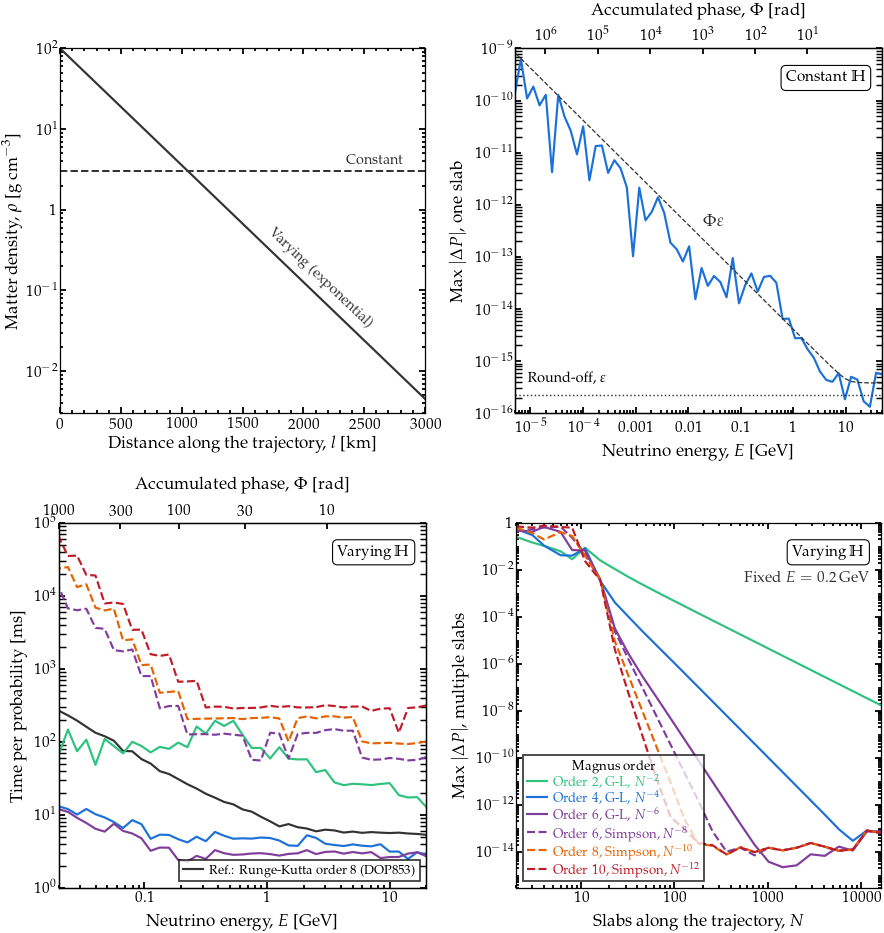

In [10]:
def label_along(ax, xs, ys, i, text, color, fontsize=8.0, offset=(4, 4), chord=False):
    """Label a curve in place, rotated to the angle its curve makes ON THE PAGE.

    A fixed rotation cannot serve six slopes differing by a factor of six: it put the
    shallowest label through its own curve and the steepest one off the edge.  The angle
    is read from ``ax.transData``, so this must be called once the geometry is final.
    """
    if chord:
        # The angle a straight label needs is the one of the chord it actually spans,
        # not the tangent at its anchor.  On a curve that steepens under the words --
        # the solar profile does -- the tangent is the shallower of the two, and the
        # curve closes on the text and cuts through it before the last character.
        f = ax.figure
        f.canvas.draw()
        probe = ax.text(0, 0, text, fontsize=fontsize)
        w = probe.get_window_extent(f.canvas.get_renderer()).width
        probe.remove()
        P = ax.transData.transform(np.column_stack([np.asarray(xs), np.asarray(ys)]))
        m = i
        while m < len(xs) - 1 and P[m, 0] - P[i, 0] < w:
            m += 1
        a, b = P[i], P[m]
    else:
        j, k = max(i - 1, 0), min(i + 1, len(xs) - 1)
        a = ax.transData.transform((xs[j], ys[j]))
        b = ax.transData.transform((xs[k], ys[k]))
    ax.annotate(text, xy=(xs[i], ys[i]), xytext=offset, textcoords='offset points',
                color=color, fontsize=fontsize,
                rotation=np.degrees(np.arctan2(b[1] - a[1], b[0] - a[0])),
                rotation_mode='anchor')


def phase_axis(axis, energy, phase, ticks, powers=False):
    r"""A secondary top axis carrying the accumulated phase.

    The phase is what a stepping solver's cost tracks, but it is not a dial: what a user
    sets is the energy, so the energy carries the primary axis.  The two are not
    reciprocal.  Below about $0.2$ GeV the vacuum term dominates and $\Phi$ goes as
    $1/E$; above it the matter potential fixes the eigenvalue splitting and $\Phi$ barely
    moves, so a thousandfold in energy is only a hundred and fiftyfold in phase.  The top
    ticks are therefore unevenly spaced, which is the physics rather than a defect.
    """
    o = np.argsort(phase)
    tw = axis.twiny()
    tw.set_xscale('log')
    tw.set_xlim(axis.get_xlim())
    tw.set_xticks(np.exp(np.interp(np.log(ticks), np.log(np.asarray(phase)[o]),
                                   np.log(np.asarray(energy)[o]))))
    # Powers of ten only where every tick is one.  Writing half-decades that way rounds
    # 30 and 300 onto 10^1 and 10^2, which prints the same label twice.
    tw.set_xticklabels([(r'$10^{%d}$' % round(np.log10(t))) if powers else ('%g' % t)
                        for t in ticks])
    tw.set_xlabel(r'Accumulated phase, $\Phi$ [rad]', labelpad=8.5, fontsize=9.5)
    # Ticks point inward, so the labels have to be pushed clear of the spine or they
    # sit on top of it.
    tw.tick_params(axis='x', direction='in', which='both', top=True, pad=2.2, labelsize=8.5)
    # Only the twin's OWN x minors.  minorticks_off() would take the y axis with it,
    # and twiny() shares that axis with the panel underneath --- which silently
    # stripped the minor ticks off both panels that carry a phase axis.
    tw.xaxis.set_minor_locator(NullLocator())
    return tw


fig = plt.figure(figsize=(WIDE, 7.48))
gs = fig.add_gridspec(2, 2, hspace=0.30, wspace=0.24)
axd = fig.add_subplot(gs[0, 0])
ax = [fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]

l_km = np.linspace(0.0, 3000.0, 600)
axd.semilogy(l_km, RHO0_2*np.exp(-l_km/LS_KM_2), '-', color=INK, lw=1.2)
axd.axhline(RHO_CONST, color=INK, ls='--', lw=1.1)
axd.set_xlim(0.0, 3000.0); axd.set_ylim(3.0e-3, 1.0e2)
axd.set_xlabel(r'Distance along the trajectory, $l$ [km]', labelpad=1.5)
axd.set_ylabel(r'Matter density, $\rho$ [g cm$^{-3}$]', labelpad=2.0)
logy(axd)
unit_as_one(axd)
RHO_EXP = RHO0_2*np.exp(-l_km/LS_KM_2)

ax[0].loglog(E_CONST/gd.UNIT_GEV, err_a, '-', color=BLUE, lw=1.2)
ax[0].axhline(2.2e-16, color=INK, ls=':', lw=0.8)
ax[0].loglog(E_CONST/gd.UNIT_GEV, np.maximum(phase_a*2.2e-16, 2.2e-16), ls='--',
             color=INK, lw=0.7)
stamp(ax[0], r'Round-off, $\varepsilon$', y=0.075)
ax[0].set_xlabel(r'Neutrino energy, $E$ [GeV]')
ax[0].set_ylabel(r'Max $|\Delta P|$, one slab')
ax[0].set_ylim(1.0e-16, 1.0e-9)
logx(ax[0]); logy(ax[0]); snug(ax[0], E_CONST/gd.UNIT_GEV)
# Every decade carries a label; the default locator thins them once the range is
# this deep, which leaves the panel with three ticks over eight decades.
ax[0].yaxis.set_major_locator(LogLocator(base=10.0, numticks=20))
# Minor ticks between the decades, and the energy labels pushed clear of the spine
# that the inward-pointing ticks share with them.
minor_log_ticks(ax[0])
ax[0].tick_params(axis='x', which='major', pad=4.2)
corner(ax[0], r'Constant $\mathbb{H}$', x=0.955, y=0.94)

E_row = np.array([r['E'] for r in rows])
# Only the solver is named here.  The six Magnus configurations are named in the panel
# beside it, where the rate they converge at belongs; colour and line style are the same
# in both, so one legend identifies them twice.
for name, lab, col, ls, meth, order in CODES:
    ax[1].loglog(E_row, 1e3*times[name], ls=ls, color=col, lw=1.2,
                 label=(lab if meth is None else '_nolegend_'))
ax[1].set_xlabel(r'Neutrino energy, $E$ [GeV]')
ax[1].set_ylabel(r'Time per probability [ms]')
ax[1].set_ylim(1.0, 1.0e5)
# Five decades now that the cumulative-quadrature curves reach a minute per
# probability, so the ticks go by decade rather than by halves.
ax[1].yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=20))
unit_as_one(ax[1])
minor_log_ticks(ax[1])
logx(ax[1]); logy(ax[1]); snug(ax[1], E_row)
corner(ax[1], r'Varying $\mathbb{H}$', x=0.955, y=0.94)
ax[1].legend(loc='lower right', handlelength=1.5,
             fontsize=7.2, labelspacing=0.2, borderpad=0.3, handletextpad=0.5,
             framealpha=0.75)

STYLE = {k: (ORDER_COLOR[k[1]], '-' if k[0] == 'gl' else '--') for k in SERIES}
LABELS = {('gl',2):'Order 2, G-L', ('gl',4):'Order 4, G-L',
          ('gl',6):'Order 6, G-L', ('simpson',6):'Order 6, Simpson',
          ('simpson',8):'Order 8, Simpson', ('simpson',10):'Order 10, Simpson'}
for k in SERIES:
    col, ls = STYLE[k]
    ax[2].loglog(NS, curves[k], ls=ls, color=col, lw=1.2,
                 label=r'%s, $N^{%d}$' % (LABELS[k], POWERS[k]))
ax[2].set_xlabel(r'Slabs along the trajectory, $N$')
ax[2].set_ylabel(r'Max $|\Delta P|$, multiple slabs')
logx(ax[2]); logy(ax[2]); snug(ax[2], NS)
ax[2].set_ylim(3.0e-16, 1.0)
unit_as_one(ax[2])
corner(ax[2], r'Varying $\mathbb{H}$', x=0.955, y=0.94)
# Flush with the *border* of the box above it, not with the text inside it: the box
# adds 0.32 of its font size as padding, so the two align only once that is added back.
ax[2].annotate(r'Fixed $E = %g$ GeV' % (E_FIX/gd.UNIT_GEV), xy=(0.955, 0.868),
               xycoords='axes fraction', xytext=(0.32*8.5 + 0.3, 0),
               textcoords='offset points', ha='right', va='top', fontsize=8.5,
               color=INK, zorder=10)
# The six configurations are named here rather than in the cost panel, because the rate
# each converges at is what this panel measures.  Each entry is set in its curve's colour.
_leg = ax[2].legend(loc='lower left', handlelength=1.5, fontsize=7.4, labelspacing=0.2,
                    borderpad=0.3, handletextpad=0.5, title='Magnus order',
                    framealpha=0.75)
_leg.get_title().set_fontsize(7.4)
for _txt, _k in zip(_leg.get_texts(), SERIES):
    _txt.set_color(STYLE[_k][0])

# Square panels: the box aspect is set on the axes rather than left to the figure shape,
# so it survives whatever the layout does to the margins.
for _a in [axd] + list(ax):
    _a.set_box_aspect(1.0)
# Margins are set explicitly rather than by tight_layout, whose layout engine re-runs at
# draw time -- when the twinned axes below exist and it cannot place them.  Fixing the
# margins here makes the geometry deterministic and lets the twins be added safely.
# Sized so the cells are square before set_box_aspect has to shrink anything: leftover
# slack inside a cell is what opens the gaps between panels.
fig.subplots_adjust(left=0.108, right=0.985, top=0.935, bottom=0.072,
                    wspace=0.20, hspace=0.26)
# The profile labels ride their own curves, at the angle the curve makes on the page.
label_along(axd, l_km, RHO_EXP, 330, 'Varying (exponential)', INK, fontsize=8.0,
            offset=(4, 5))
label_along(axd, l_km, np.full_like(l_km, RHO_CONST), 470, 'Constant', INK, fontsize=8.0,
            offset=(0, 4))
phase_axis(ax[0], E_CONST/gd.UNIT_GEV, phase_a,
           [10, 100, 1000, 10000, 100000, 1000000], powers=True)
# The rising guide carries its own name, upright and at the middle of its own line:
# rotating it to the curve angle left the epsilon unreadable at this size, and a stamp
# cannot say which of the two guides it means.
_g = np.maximum(phase_a*2.2e-16, 2.2e-16)
_i = len(_g)//2
ax[0].annotate(r'$\Phi\varepsilon$', xy=(E_CONST[_i]/gd.UNIT_GEV, _g[_i]),
               xytext=(4, 3.5), textcoords='offset points', color=INK, fontsize=9.5)
phase_axis(ax[1], E_row, ph, [10, 30, 100, 300, 1000])
save(fig, 'phase_vs_profile.pdf')

## Figure 3 --- new physics, four matrices in one slot

All four panels are the survival channel. The rows sit three decades apart in energy
because the two families of new physics do.

**The standard curve is flat at one in the lower row and that is physics, not an
artifact**: the vacuum term falls as $1/E$, so above about 100 GeV the active sector has
stopped oscillating over an Earth chord. The cell prints the range it spans.

five scenarios, survival channel, in 3.7 s
  b3 = 5.406e-14 eV; LIV departs from standard by up to 0.976
  standard at 1-30 TeV spans 0.9988-1.0000: the vacuum term goes as 1/E and has switched off


  wrote /home/mbustamante/Research/magnus/resources/paper/figs/bsm.pdf


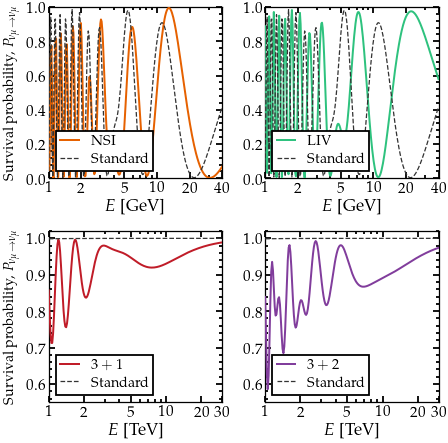

In [11]:
COSTHZ = -0.9
L = chord(COSTHZ)
LIV = dict(b1=0.0, b2=0.0, b3=np.pi/L, Lambda=1.0, sxi12=0.0,
           sxi23=1.0/np.sqrt(2.0), sxi13=0.0, dxiCP=0.0, n_liv=0)
KW = dict(nu_i=gd.NUMU, nu_f=gd.NUMU, rtol=RTOL_FIG, atol=ATOL_FIG)

E_GEV = np.logspace(np.log10(1.0), np.log10(40.0), 260)*gd.UNIT_GEV
E_TEV = np.logspace(np.log10(1.0), np.log10(30.0), 200)*gd.UNIT_TEV

t0 = time.perf_counter()
std_gev = np.asarray(quiet(oscprob.osc_prob_3nu_earth, E_GEV, costhz=COSTHZ, L=L,
                           **OSC, **KW))
nsi_gev = np.asarray(quiet(oscprob.osc_prob_3nu_earth_nsi, E_GEV, costhz=COSTHZ, L=L,
                           **OSC, **EPS, **KW))
liv_gev = np.asarray(quiet(oscprob.osc_prob_3nu_earth_liv, E_GEV, costhz=COSTHZ, L=L,
                           **OSC, **LIV, **KW))
std_tev = np.asarray(quiet(oscprob.osc_prob_3nu_earth, E_TEV, costhz=COSTHZ, L=L,
                           **OSC, **KW))
ste1_tev = np.asarray(quiet(oscprob.osc_prob_4nu_earth, E_TEV, costhz=COSTHZ, L=L,
                            **OSC, **STERILE4, **KW))
ste2_tev = np.asarray(quiet(oscprob.osc_prob_5nu_earth, E_TEV, costhz=COSTHZ, L=L,
                            **OSC, **STERILE5, **KW))
print('five scenarios, survival channel, in %.1f s' % (time.perf_counter() - t0))
print('  b3 = %.3e eV; LIV departs from standard by up to %.3f'
      % (LIV['b3'], np.max(np.abs(liv_gev - std_gev))))
print('  standard at 1-30 TeV spans %.4f-%.4f: the vacuum term goes as 1/E and has'
      ' switched off' % (std_tev.min(), std_tev.max()))

PANELS = [(E_GEV/gd.UNIT_GEV, std_gev, nsi_gev, ORANGE, 'NSI', r'$E$ [GeV]'),
          (E_GEV/gd.UNIT_GEV, std_gev, liv_gev, GREEN, 'LIV', r'$E$ [GeV]'),
          (E_TEV/gd.UNIT_TEV, std_tev, ste1_tev, RED, r'$3+1$', r'$E$ [TeV]'),
          (E_TEV/gd.UNIT_TEV, std_tev, ste2_tev, PURPLE, r'$3+2$', r'$E$ [TeV]')]
fig, axes = plt.subplots(2, 2, figsize=(COL, 3.45))
YLIM = {0: (0.0, 1.0), 1: (0.55, 1.02)}
TICKS = {r'$E$ [GeV]': (1, 2, 5, 10, 20, 40), r'$E$ [TeV]': (1, 2, 5, 10, 20, 30)}
for k, (ax, (x, base, curve, color, label, xl)) in enumerate(zip(axes.ravel(), PANELS)):
    ax.plot(x, curve, color=color, lw=1.1, zorder=3, label=label)
    ax.plot(x, base, color=INK, lw=0.7, ls='--', zorder=4, label='Standard')
    logx(ax); snug(ax, x); xticks_at(ax, TICKS[xl])
    ax.set_ylim(*YLIM[k//2]); minor_y(ax, 5)
    ax.set_xlabel(xl, labelpad=1.5)
    ax.legend(loc='lower left', handlelength=1.3, labelspacing=0.2, fontsize=8.0)
for ax in axes[:, 0]:
    ax.set_ylabel(r'Survival probability, $P_{\nu_\mu \to \nu_\mu}$', fontsize=8.0)
fig.tight_layout(pad=0.3, w_pad=0.8, h_pad=0.9)
save(fig, 'bsm.pdf')

## Figure 4 --- three oscillograms

**The middle row carries its own energy axis and cannot share the others'.** An eV-scale
sterile splitting over an 11 000 km chord oscillates far too fast at GeV energies for any
grid to represent --- and far too slowly to compute: one row of 200 energies costs 0.56 s
at three flavors and 21 s at 3+1, which is an hour for the panel and aliasing for the
result. At TeV energies the sterile matter resonance is the feature and the panel costs
seconds.

  oscillogram_Earth_3_nu read from paper_figure_cache.json, unchanged configuration 0b52364a6f45 (measured 2026-08-31 on laptop-6)
  oscillogram_Earth_3_nu_NSI read from paper_figure_cache.json, unchanged configuration a42e9a778f06 (measured 2026-08-31 on laptop-6)


  oscillogram_Earth_3_1 read from paper_figure_cache.json, unchanged configuration b9ff43f77108 (measured 2026-08-31 on laptop-6)
  oscillogram_Earth_3_2 read from paper_figure_cache.json, unchanged configuration 1ec8fd69cb7c (measured 2026-08-31 on laptop-6)


  wrote /home/mbustamante/Research/magnus/resources/paper/figs/earth_oscillogram.pdf


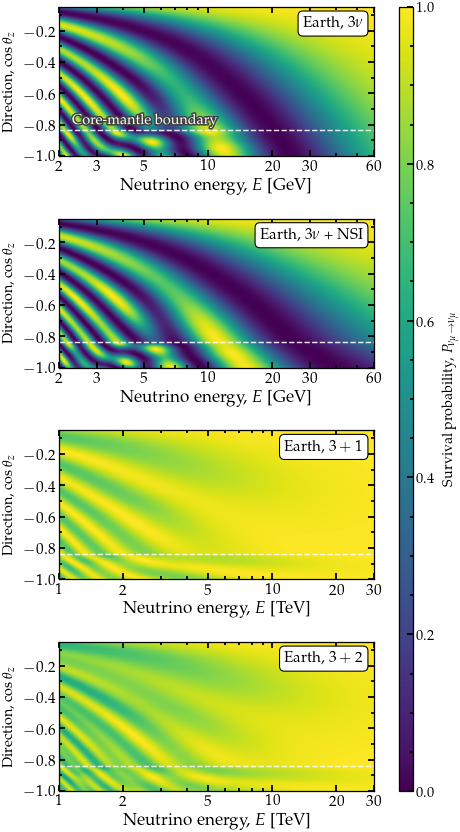

In [12]:
# ------------------------------------------------------- three oscillograms
# Each row carries its own energy window, and it has to.  An eV-scale sterile
# splitting over an 11 000 km chord oscillates far too fast at GeV energies for any
# grid to represent -- and far too slowly to compute: one row of 200 energies costs
# 0.56 s at three flavors and 21 s at 3+1 there, which is an hour for the panel and
# aliasing for the result.  At TeV energies the sterile matter resonance is the
# feature, the phase is small, and the panel costs seconds.
NE, NZ = 200, 170
E_GEV_OSC = np.logspace(np.log10(2.0), np.log10(60.0), NE)*gd.UNIT_GEV
E_TEV_OSC = np.logspace(np.log10(1.0), np.log10(30.0), NE)*gd.UNIT_TEV
CZ = np.linspace(-1.0, -0.05, NZ)
GEV_TICKS, TEV_TICKS = (2, 3, 5, 10, 20, 30, 60), (1, 2, 5, 10, 20, 30)

SCEN = [
    (r'Earth, $3\nu$', E_GEV_OSC, gd.UNIT_GEV, r'Neutrino energy, $E$ [GeV]',
     GEV_TICKS,
     lambda E, cz, Lc: oscprob.osc_prob_3nu_earth(
         E, costhz=cz, L=Lc, nu_i=gd.NUMU, nu_f=gd.NUMU, rtol=RTOL_FIG,
         atol=ATOL_FIG, **OSC)),
    (r'Earth, $3\nu$ + NSI', E_GEV_OSC, gd.UNIT_GEV, r'Neutrino energy, $E$ [GeV]',
     GEV_TICKS,
     lambda E, cz, Lc: oscprob.osc_prob_3nu_earth_nsi(
         E, costhz=cz, L=Lc, nu_i=gd.NUMU, nu_f=gd.NUMU, rtol=RTOL_FIG,
         atol=ATOL_FIG, **OSC, **EPS)),
    (r'Earth, $3+1$', E_TEV_OSC, gd.UNIT_TEV, r'Neutrino energy, $E$ [TeV]',
     TEV_TICKS,
     lambda E, cz, Lc: oscprob.osc_prob_4nu_earth(
         E, costhz=cz, L=Lc, nu_i=gd.NUMU, nu_f=gd.NUMU, rtol=RTOL_FIG,
         atol=ATOL_FIG, **OSC, **STERILE4)),
    # The wrapper takes s25 but has no d25: the phase is not independent there, so we
    # pass the angles and leave every CP phase of the sterile sector at its default.
    (r'Earth, $3+2$', E_TEV_OSC, gd.UNIT_TEV, r'Neutrino energy, $E$ [TeV]',
     TEV_TICKS,
     lambda E, cz, Lc: oscprob.osc_prob_5nu_earth(
         E, costhz=cz, L=Lc, nu_i=gd.NUMU, nu_f=gd.NUMU, rtol=RTOL_FIG,
         atol=ATOL_FIG, **OSC, **STERILE5)),
]

fig, axes = plt.subplots(4, 1, figsize=(COL, 7.3),
                         gridspec_kw=dict(hspace=0.42))
def oscillogram_grid(label, E_ax, call):
    """One panel's worth of probability, computed once and read from disk after.

    Four panels of 170 x 200 points are about three minutes, and every one of those
    points is a function of the configuration rather than of the run.  Cosmetic work on
    this figure -- a tick label, a colorbar -- must not pay for them again.
    """
    def run():
        grid = np.empty((NZ, NE))
        for i, cz in enumerate(CZ):
            grid[i] = np.asarray(quiet(call, E_ax, float(cz), chord(float(cz))))
        return grid.tolist()
    key = ('oscillogram', label, [float(e) for e in E_ax], [float(c) for c in CZ],
           RTOL_FIG, ATOL_FIG, sorted(OSC.items()), sorted(STERILE4.items()),
           sorted(STERILE5.items()), sorted((k, str(v)) for k, v in EPS.items()))
    return np.asarray(cached('oscillogram_%s' % re.sub(r'\W+', '_', label).strip('_'),
                             key, run, what='one oscillogram panel'))


for ax, (label, E_ax, unit, xlabel, ticks, call) in zip(axes, SCEN):
    grid = oscillogram_grid(label, E_ax, call)
    im = ax.pcolormesh(E_ax/unit, CZ, grid, cmap='viridis', vmin=0.0, vmax=1.0,
                       shading='gouraud', rasterized=True)
    logx(ax); snug(ax, E_ax/unit); xticks_at(ax, ticks)
    ax.set_ylim(CZ.min(), CZ.max())
    ax.set_yticks(np.arange(-1.0, 0.0, 0.2)); minor_y(ax, 2)
    ax.set_ylabel(r'Direction, $\cos\theta_z$', fontsize=8.0)
    ax.set_xlabel(xlabel, labelpad=1.5)
    ax.axhline(-0.837, color='w', lw=0.8, ls='--', alpha=0.9)
    corner(ax, label, fontsize=8.5)
axes[0].text(2.3, -0.822, 'Core-mantle boundary', color='white', fontsize=8.0,
             va='bottom', path_effects=[pe.withStroke(linewidth=1.6, foreground='0.25')])
# aspect follows the panel count, so the bar is as tall as the stack beside it.
cb = fig.colorbar(im, ax=list(axes), pad=0.07, fraction=0.045, aspect=56)
cb.set_label(r'Survival probability, $P_{\nu_\mu \to \nu_\mu}$', fontsize=8.0)
cb.ax.tick_params(labelsize=8.0)
save(fig, 'earth_oscillogram.pdf')

## Figure 5 --- the Sun: model, observable, and residual

The reference in the bottom panel is the adiabatic limit built from the instantaneous
eigenbases alone --- two calls to `eigh` and a contraction, touching none of the package's
averaging machinery, so it works for all three scenarios rather than only the standard
one.

One trap paid for here: `hamiltonian_3nu_nsi` returns $V_{\rm CC}$ times the epsilon matrix
**alone** --- it is zero when every epsilon is --- so the standard matter term has to be
added beside it. Omitting it put this reference 0.178 away from the answer instead of
1e-5, which reads as a spectacular disagreement rather than as a missing term.

In [13]:
TABLE = os.path.join('..', 'docs', 'dev', 'adversarial_batteries', 'bs05_agsop.dat')
rows = []
with open(TABLE) as fh:
    for line in fh:
        f = line.split()
        if len(f) == 12:
            try:
                rows.append([float(x) for x in f])
            except ValueError:
                continue
solar = np.array(rows)
r_over_rsun, rho_cgs, x_h = solar[:, 1], solar[:, 3], solar[:, 6]
MEAN_NUCLEON = 0.5*(gd.MASS_PROTON + gd.MASS_NEUTRON)
ne_tab = rho_cgs*gd.UNIT_G_PER_CM3/MEAN_NUCLEON*(0.5*(1.0 + x_h))
x_solar = r_over_rsun*gd.SUN_RADIUS*gd.UNIT_KM
log_ne = np.log(ne_tab)
R_SUN = float(x_solar[-1])


def ne_sun(l):
    xs = np.clip(np.asarray(l, dtype=float), x_solar[0], x_solar[-1])
    out = np.exp(np.interp(xs, x_solar, log_ne))
    return out[()] if np.ndim(out) == 0 else out


PER_NE = matter.VCC_func(l=0.0, num_density_e_func=lambda l: 1.0)
print('BS2005-AGS,OP: %d rows, ray 0 to %.0f km; n_e falls by %.1e over it'
      % (len(solar), R_SUN/gd.UNIT_KM, ne_tab[0]/ne_tab[-1]))


def adiabatic_limit(build_H, energy, vcc0, a=gd.NUE, b=gd.NUE):
    r"""The decohered adiabatic limit, from the instantaneous eigenbases alone.

    Decohere in the matter eigenbasis at production, transport along the levels, read
    out in the vacuum eigenbasis at the surface.  This touches none of the package's
    averaging machinery -- two calls to ``eigh`` and a contraction -- so it is an
    independent reference for every scenario rather than only for the standard one,
    where it reduces to the textbook MSW expression.
    """
    hv = np.asarray(build_H(energy, 0.0), dtype=complex)
    hm = np.asarray(build_H(energy, vcc0), dtype=complex)
    _, u_matter = np.linalg.eigh(hm)
    _, u_vac = np.linalg.eigh(hv)
    return float(np.sum(np.abs(u_matter[a])**2 * np.abs(u_vac[b])**2))


OSC4 = dict(OSC); OSC4.update(STERILE4); OSC4.update(d14=0.0, d24=0.0)
OSC5 = dict(OSC); OSC5.update(STERILE5)
OSC5.update(d14=0.0, d24=0.0, d15=0.0, d25=0.0, d35=0.0)
E_AVG = np.logspace(np.log10(0.1), np.log10(20.0), 90)*gd.UNIT_MEV
COMMON = dict(L0=0.0, nu_i=gd.NUE, nu_f=gd.NUE, density_is_of_number_of_electrons=True)
VCC0 = float(PER_NE*ne_sun(0.0))

HV3 = np.asarray(vacuum_hamiltonian(3), dtype=complex)
HV4 = np.asarray(vacuum_hamiltonian(4), dtype=complex)
HV5 = np.asarray(vacuum_hamiltonian(5), dtype=complex)
P3 = np.asarray(matter.matter_potential_projector(3), dtype=complex)
P4 = np.asarray(matter.matter_potential_projector(4), dtype=complex)
P5 = np.asarray(matter.matter_potential_projector(5), dtype=complex)
EPS_ORDER = ('eps_ee', 'eps_em', 'eps_et', 'eps_mm', 'eps_mt', 'eps_tt')

# 3nu, then the NSI case, then the two steriles: the order the middle panel reads in.
SCEN = [
    (r'$3\nu$', BLUE,
     lambda E: oscprob.osc_prob_matter_std_potential(3, ne_sun, E, R_SUN, OSC,
                                                     average=True, **COMMON),
     lambda E, v: HV3/E + v*P3),
    (r'$3\nu$ + NSI', ORANGE,
     lambda E: oscprob.osc_prob_matter_nsi(3, ne_sun, E, R_SUN, OSC, EPS,
                                           average=True, **COMMON),
     # hamiltonian_3nu_nsi returns V_CC times the epsilon matrix ALONE -- it is zero
     # when every epsilon is -- so the standard matter term has to be added beside it.
     # Omitting it put this reference 0.178 away from the answer rather than 1e-5.
     lambda E, v: HV3/E + v*P3 + np.asarray(hamiltonians.hamiltonian_3nu_nsi(
         v, *[EPS[k] for k in EPS_ORDER]), dtype=complex)),
    (r'$3+1$', RED,
     lambda E: oscprob.osc_prob_matter_std_potential(4, ne_sun, E, R_SUN, OSC4,
                                                     average=True, **COMMON),
     lambda E, v: HV4/E + v*P4),
    # Green, not purple: purple marks the resonance densities in the panel above.
    (r'$3+2$', GREEN,
     lambda E: oscprob.osc_prob_matter_std_potential(5, ne_sun, E, R_SUN, OSC5,
                                                     average=True, **COMMON),
     lambda E, v: HV5/E + v*P5),
]

BS2005-AGS,OP: 1284 rows, ray 0 to 682946 km; n_e falls by 1.2e+05 over it


  central n_e = 6.13e+25 cm^-3 (the Sun's core is ~6e25)
  solar_3_nu read from paper_figure_cache.json, unchanged configuration 28632163f4ca (measured 2026-08-31 on laptop-6)
$3\nu$         P in 0.299-0.545, worst |Magnus - adiabatic| 1.28e-05
  solar_3_nu_NSI read from paper_figure_cache.json, unchanged configuration 8fd284046950 (measured 2026-08-31 on laptop-6)
$3\nu$ + NSI   P in 0.301-0.544, worst |Magnus - adiabatic| 1.49e-05
  solar_3_1 read from paper_figure_cache.json, unchanged configuration f542b020edf1 (measured 2026-08-31 on laptop-6)
$3+1$          P in 0.257-0.452, worst |Magnus - adiabatic| 9.65e-06


  solar_3_2 read from paper_figure_cache.json, unchanged configuration 1832ce784a72 (measured 2026-08-31 on laptop-6)
$3+2$          P in 0.234-0.403, worst |Magnus - adiabatic| 8.09e-06


  wrote /home/mbustamante/Research/magnus/resources/paper/figs/solar_averaged.pdf


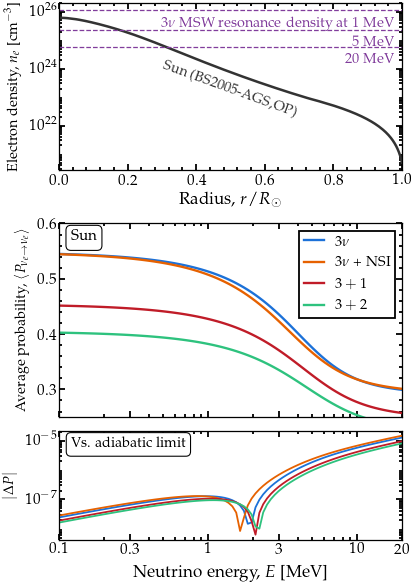

In [14]:
fig = plt.figure(figsize=(COL, 5.0))
outer = fig.add_gridspec(2, 1, height_ratios=[1.22, 2.30], hspace=0.22)
gs_low = outer[1].subgridspec(2, 1, height_ratios=[1.60, 0.90], hspace=0.09)
axes = [fig.add_subplot(outer[0]), fig.add_subplot(gs_low[0]), None]
axes[2] = fig.add_subplot(gs_low[1], sharex=axes[1])

# --- the model
ax = axes[0]
rr = x_solar/R_SUN
# n_e in cm^-3: natural units cube the energy, and nobody quotes a solar electron
# density that way.  gd.UNIT_PER_CM3 is one cm^-3 expressed in eV^3.
PER_CM3 = gd.UNIT_PER_CM3
print('  central n_e = %.2e cm^-3 (the Sun\'s core is ~6e25)' % (ne_tab[0]/PER_CM3))
ax.semilogy(rr, ne_tab/PER_CM3, color=INK, lw=1.4)
cos2th12 = 1.0 - 2.0*OSC['s12']**2
# Staggered horizontally: the three resonance densities are within a decade of each
# other, so labels at a common x sit on top of one another.
# The first label carries the whole statement; the other two need only their energy,
# right-aligned under it so the three read as one column.
LAB = {1.0: r'$3\nu$ MSW resonance density at 1 MeV', 5.0: '5 MeV', 20.0: '20 MeV'}
for Emev in (1.0, 5.0, 20.0):
    nr = OSC['D21']*cos2th12/(2.0*Emev*gd.UNIT_MEV)/PER_NE
    ax.axhline(nr/PER_CM3, color=PURPLE, lw=0.7, ls='--')
    # Under its own line, clear of it: the top line sits at the very top of the panel,
    # so a label placed above it lands outside the axes.
    ax.annotate(LAB[Emev], xy=(0.975, nr/PER_CM3), xytext=(0, -3.5),
                textcoords='offset points', color=PURPLE, fontsize=8.0, ha='right',
                va='top')
logy(ax); ax.set_xlim(0.0, 1.0)
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.set_xlabel(r'Radius, $r/R_\odot$', labelpad=1.5)
ax.set_ylabel(r'Electron density, $n_e$ [cm$^{-3}$]', fontsize=8.0)


# --- the averaged observable, and the residual under it
resid = {}
for label, color, call, build_H in SCEN:
    def run(call=call, build_H=build_H):
        P = np.asarray(quiet(call, E_AVG))
        R = np.array([adiabatic_limit(build_H, e, VCC0) for e in E_AVG])
        return dict(P=P.tolist(), R=R.tolist())
    got = cached('solar_%s' % re.sub(r'\W+', '_', label).strip('_'),
                 ('solar', label, [float(e) for e in E_AVG], float(R_SUN),
                  profile_samples(lambda l: PER_NE*ne_sun(l), R_SUN),
                  sorted(OSC.items())),
                 run, what='one averaged solar scenario')
    P, R = np.asarray(got['P']), np.asarray(got['R'])
    axes[1].semilogx(E_AVG/gd.UNIT_MEV, P, color=color, lw=1.3, label=label)
    resid[label] = (color, np.abs(P - R))
    print('%-14s P in %.3f-%.3f, worst |Magnus - adiabatic| %.2e'
          % (label, P.min(), P.max(), resid[label][1].max()))

a = axes[1]
logx(a); snug(a, E_AVG/gd.UNIT_MEV); xticks_at(a, (0.1, 0.3, 1, 3, 10, 20))
a.set_ylim(0.25, 0.60); minor_y(a, 5)
a.set_ylabel(r'Average probability, $\langle P_{\nu_e \to \nu_e}\rangle$',
             fontsize=8.0)
a.tick_params(labelbottom=False)
a.legend(loc='upper right', handlelength=1.4)
corner(a, r'Sun', loc='upper left', x=0.035, y=0.965)

b = axes[2]
for label, (color, dP) in resid.items():
    b.semilogy(E_AVG/gd.UNIT_MEV, np.maximum(dP, 1.0e-17), color=color, lw=1.0)
logx(b); logy(b); snug(b, E_AVG/gd.UNIT_MEV); xticks_at(b, (0.1, 0.3, 1, 3, 10, 20))
b.set_xlabel(r'Neutrino energy, $E$ [MeV]')
b.set_ylabel(r'$|\Delta P|$', fontsize=8.0)
corner(b, r'Vs.\ adiabatic limit', loc='upper left', x=0.035, y=0.94,
       fontsize=8.0)
fig.subplots_adjust(left=0.20)
# Along the curve, and last: label_along reads the slope off transData, so it has to
# run once the axes have their final width.  Called before subplots_adjust, it was
# rotated to an angle the panel no longer had, and the curve cut through the words.
# Anchored by radius, not by index: the model table is sampled far more densely in
# the core, so a fraction of len(rr) lands nowhere near that fraction of the Sun.
label_along(ax, rr, ne_tab/PER_CM3, int(np.searchsorted(rr, 0.30)),
            'Sun (BS2005-AGS,OP)', INK, fontsize=8.0, offset=(0, -13), chord=True)
save(fig, 'solar_averaged.pdf')

### Figure 5b --- a Hamiltonian the package never heard of

A gauged $L_e - L_\mu$ symmetry adds a long-range potential sourced by the electrons of the
Sun itself. Nothing about it is built in: it is a callable returning a Hermitian matrix,
which is the whole of the interface.

L_e - L_mu, 1/m = 1.0 R_sun: V_new/V_CC = 0.100 at the center, 2.4884 at 0.5 R_sun
L_e - L_mu, 1/m = 0.1 R_sun: V_new/V_CC = 0.100 at the center, 0.3799 at 0.5 R_sun
  solar_long_range read from paper_figure_cache.json, unchanged configuration 4410c58df810 (measured 2026-08-31 on laptop-6)
  P_ee standard 0.299-0.545
    1/m = 1.0 R_sun: 0.318-0.544, largest shift 0.021
    1/m = 0.1 R_sun: 0.297-0.544, largest shift 0.018


  wrote /home/mbustamante/Research/magnus/resources/paper/figs/solar_long_range.pdf


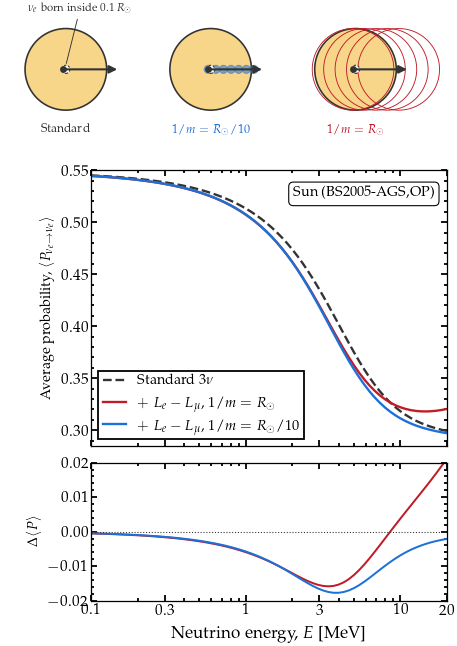

In [15]:
# ------------------------------------------------ Figure 5b: L_e - L_mu in the Sun
def running_integral(y, x):
    """Trapezoidal running integral of y over x, zero at the first node."""
    return np.concatenate([[0.0], np.cumsum(0.5*(y[1:] + y[:-1])*np.diff(x))])


def shc(x):
    """sinh(x)/x, continued to 1 at the origin."""
    x = np.asarray(x, dtype=float)
    out = np.ones_like(x)
    big = np.abs(x) > 1.0e-8
    out[big] = np.sinh(x[big])/x[big]
    return out


def long_range_potential(r_grid, ne_grid, m):
    """V_{e-mu}(r) on r_grid, in units of g'^2, for a spherical n_e(r)."""
    inner = r_grid**2*ne_grid*shc(m*r_grid)
    outer = r_grid*ne_grid*np.exp(-m*r_grid)
    I_in = running_integral(inner, r_grid)
    running_out = running_integral(outer, r_grid)
    I_out = running_out[-1] - running_out
    r_safe = np.where(r_grid > 0.0, r_grid, 1.0e-30)
    return np.exp(-m*r_grid)*I_in/r_safe + shc(m*r_grid)*I_out


LR_CHARGE = np.diag([1.0, -1.0, 0.0]).astype(complex)      # the L_e - L_mu charge
# Two mediator ranges: the solar radius, the analogue of 1/m = R_earth in notebook 19,
# and a tenth of it.  The shorter range samples the profile where it is steepest, so the
# two are not a rescaling of each other.
LR_RANGES = [(1.0, r'$1/m = R_\odot$', RED),
             (0.1, r'$1/m = R_\odot/10$', BLUE)]
V_LR = {}
G2 = {}
for frac, _, _ in LR_RANGES:
    V_LR[frac] = long_range_potential(x_solar, ne_tab, 1.0/(frac*R_SUN))
    # g'^2 fixed so the new potential is a tenth of V_CC at the center in each case,
    # which is what makes the two curves comparable.
    G2[frac] = 0.1*VCC0/V_LR[frac][0]
    print('L_e - L_mu, 1/m = %.1f R_sun: V_new/V_CC = %.3f at the center, %.4f at 0.5 R_sun'
          % (frac, G2[frac]*V_LR[frac][0]/VCC0,
             G2[frac]*np.interp(0.5*R_SUN, x_solar, V_LR[frac])
             / float(PER_NE*ne_sun(0.5*R_SUN))))


def H_lr(E, frac=None):
    """Standard three-flavor solar Hamiltonian, with a long-range term or without."""
    def f(l):
        v = float(PER_NE*ne_sun(l))
        h = HV3/E + v*P3
        if frac is not None:
            h = h + float(G2[frac]*np.interp(l, x_solar, V_LR[frac]))*LR_CHARGE
        return h
    return f


E_LR = np.logspace(np.log10(0.1), np.log10(20.0), 70)*gd.UNIT_MEV
avg = lambda H: avgprob.averaged_probabilities_adiabatic(H, 0.0, R_SUN)[0][0, 0]


def _lri_sweep():
    out = {'std': [avg(H_lr(e)) for e in E_LR]}
    for frac, _, _ in LR_RANGES:
        out['%g' % frac] = [avg(H_lr(e, frac)) for e in E_LR]
    return out


_got = cached('solar_long_range',
              ('lri', [float(e) for e in E_LR], float(R_SUN), [f for f, _, _ in LR_RANGES],
               {'%g' % f: float(G2[f]) for f, _, _ in LR_RANGES}, sorted(OSC.items())),
              _lri_sweep, what='the long-range solar sweep')
P_std = np.asarray(_got['std'])
P_lr = {frac: np.asarray(_got['%g' % frac]) for frac, _, _ in LR_RANGES}
print('  P_ee standard %.3f-%.3f' % (P_std.min(), P_std.max()))
for frac, lab, _ in LR_RANGES:
    print('    1/m = %.1f R_sun: %.3f-%.3f, largest shift %.3f'
          % (frac, P_lr[frac].min(), P_lr[frac].max(),
             np.max(np.abs(P_lr[frac] - P_std))))

from matplotlib.patches import Circle
# The data panels are inset to leave room for their y-labels; the diagram above them is
# given its own axes so that it can span the full column, as a schematic should.
fig = plt.figure(figsize=(COL, 5.15))
_gs = fig.add_gridspec(2, 1, height_ratios=[2.0, 1.0], hspace=0.08,
                       left=0.20, right=0.985, bottom=0.072, top=0.715)
axes = [fig.add_subplot(_gs[0]), None]
axes[1] = fig.add_subplot(_gs[1], sharex=axes[0])
axd = fig.add_axes([0.005, 0.735, 0.99, 0.255])

# What each mediator range lets the neutrino feel.  The charged-current potential is
# local, so the standard case carries no disc at all; a Yukawa term of range 1/m lets
# the neutrino feel every electron within that distance, which at 1/m = R_sun is most
# of the Sun at once and reaches past its surface.
axd.set_xlim(-1.55, 9.45); axd.set_ylim(-1.62, 1.52)
axd.set_aspect('equal'); axd.axis('off')
SUN_FILL = '#f7d68a'
R_D, CX_D, PROD_D = 1.0, [0.0, 3.55, 7.10], -0.06
for _cx, (_rng, _col, _lab) in zip(CX_D, [(None, INK, r'Standard'),
                                          (0.10, BLUE, r'$1/m = R_\odot/10$'),
                                          (1.00, RED,  r'$1/m = R_\odot$')]):
    axd.add_patch(Circle((_cx, 0), R_D, facecolor=SUN_FILL, edgecolor=INK, lw=0.9, zorder=2))
    if _rng is not None:
        # The long-range discs are outlines: filled at this radius they hide the Sun.
        for _s in np.linspace(PROD_D, 1.06, 7 if _rng < 0.5 else 5):
            axd.add_patch(Circle((_cx + _s, 0), _rng*R_D,
                                 facecolor=_col if _rng < 0.5 else 'none',
                                 alpha=0.55 if _rng < 0.5 else 1.0,
                                 edgecolor=_col, lw=0.5, zorder=5))
    axd.add_patch(Circle((_cx, 0), 0.10*R_D, facecolor='white', edgecolor=INK, lw=0.6,
                         ls=(0, (2.2, 1.6)), zorder=6))
    axd.annotate('', xy=(_cx + 1.26, 0), xytext=(_cx + PROD_D, 0), zorder=8,
                 arrowprops=dict(arrowstyle='-|>', color=INK, lw=1.15, shrinkA=0, shrinkB=0))
    axd.plot([_cx + PROD_D], [0], marker='o', ms=2.8, color=INK, zorder=9)
    axd.text(_cx, -1.34, _lab, ha='center', va='top', fontsize=6.8, color=_col)
axd.annotate(r'$\nu_e$ born inside $0.1\,R_\odot$', xy=(CX_D[0], 0.10),
             xytext=(CX_D[0] + 0.35, 1.36), ha='center', va='bottom', fontsize=6.3,
             color=INK, arrowprops=dict(arrowstyle='-', color=INK, lw=0.5,
                                        shrinkA=1, shrinkB=1))

a = axes[0]
a.semilogx(E_LR/gd.UNIT_MEV, P_std, color=INK, lw=1.3, ls='--', label=r'Standard $3\nu$')
for frac, lab, col in LR_RANGES:
    a.semilogx(E_LR/gd.UNIT_MEV, P_lr[frac], color=col, lw=1.3,
               label=r'$+\;L_e - L_\mu$,  ' + lab)
logx(a); snug(a, E_LR/gd.UNIT_MEV); xticks_at(a, (0.1, 0.3, 1, 3, 10, 20))
a.set_ylabel(r'Average probability, $\langle P_{\nu_e \to \nu_e}\rangle$', fontsize=8.0)
a.set_ylim(top=0.55)
a.tick_params(labelbottom=False); minor_y(a, 5)
a.legend(loc='lower left', handlelength=1.6)
corner(a, r'Sun (BS2005-AGS,OP)', loc='upper right', fontsize=8.0)

b = axes[1]
for frac, _, col in LR_RANGES:
    b.semilogx(E_LR/gd.UNIT_MEV, P_lr[frac] - P_std, color=col, lw=1.1)
b.axhline(0.0, color=INK, lw=0.6, ls=':')
logx(b); snug(b, E_LR/gd.UNIT_MEV); xticks_at(b, (0.1, 0.3, 1, 3, 10, 20))
b.set_xlabel(r'Neutrino energy, $E$ [MeV]')
b.set_ylabel(r'$\Delta \langle P \rangle$', fontsize=8.0)
b.set_ylim(-0.02, 0.02)
minor_y(b, 5)
save(fig, 'solar_long_range.pdf')

## Figure 6 --- a supernova shock

Rows 1 and 2 share the full-ray axis; row 3 is a window at the front and gets its own.

The front is 0.1% of the ray at most, so it cannot show on the full-ray axis --- the inset
is the only place the two columns differ to the eye. Two flavors is not drawn: with only
$\Delta m^2_{21}$ available at 15 MeV it spans 0.998 to 1.000.

**Note which engine answers.** The paper describes an adiabatic strategy at length and it
is *not* what runs here: a baseline scan at one energy goes to the cumulative engine, and
declared breakpoints make the hybrid stand aside in any case. The cell prints it.

vacuum oscillation length at 15 MeV: 494 km; the ray spans 142 of them
engine answering this figure: 'cumulative' (declined: none)
  shock_3_nu_0p07 read from paper_figure_cache.json, unchanged configuration 2f410488118e (measured 2026-08-31 on laptop-6)
  width   0.07 km  $3\nu$        full P in 0.215-1.000
  shock_3_1_0p07 read from paper_figure_cache.json, unchanged configuration 39bdf9fd29f9 (measured 2026-08-31 on laptop-6)
  width   0.07 km  $3+1$         full P in 0.045-0.999


/tmp/ipykernel_11416/806406878.py:144: MatplotlibDeprecationWarning: Since Matplotlib 3.10 indicate_inset_[zoom] returns a single InsetIndicator artist with a rectangle property and a connectors property.  From 3.12 it will no longer be possible to unpack the return value into two elements.
  rect, lines = top.indicate_inset(


  shock_3_nu_NSI_0p07 read from paper_figure_cache.json, unchanged configuration d46f10540758 (measured 2026-08-31 on laptop-6)
  width   0.07 km  $3\nu$ + NSI  full P in 0.228-1.000
  shock_3_2_0p07 read from paper_figure_cache.json, unchanged configuration 6b7eb6744658 (measured 2026-08-31 on laptop-6)
  width   0.07 km  $3+2$         full P in 0.002-0.992
  shock_3_nu_70 read from paper_figure_cache.json, unchanged configuration cd26c35913a4 (measured 2026-08-31 on laptop-6)
  width  70.00 km  $3\nu$        full P in 0.001-1.000
  shock_3_1_70 read from paper_figure_cache.json, unchanged configuration 244d3a4d32d5 (measured 2026-08-31 on laptop-6)
  width  70.00 km  $3+1$         full P in 0.007-0.999


/tmp/ipykernel_11416/806406878.py:144: MatplotlibDeprecationWarning: Since Matplotlib 3.10 indicate_inset_[zoom] returns a single InsetIndicator artist with a rectangle property and a connectors property.  From 3.12 it will no longer be possible to unpack the return value into two elements.
  rect, lines = top.indicate_inset(


  shock_3_nu_NSI_70 read from paper_figure_cache.json, unchanged configuration df2766ae9ade (measured 2026-08-31 on laptop-6)
  width  70.00 km  $3\nu$ + NSI  full P in 0.005-1.000
  shock_3_2_70 read from paper_figure_cache.json, unchanged configuration 62183edf778a (measured 2026-08-31 on laptop-6)
  width  70.00 km  $3+2$         full P in 0.077-0.992


  wrote /home/mbustamante/Research/magnus/resources/paper/figs/shock_probability.pdf


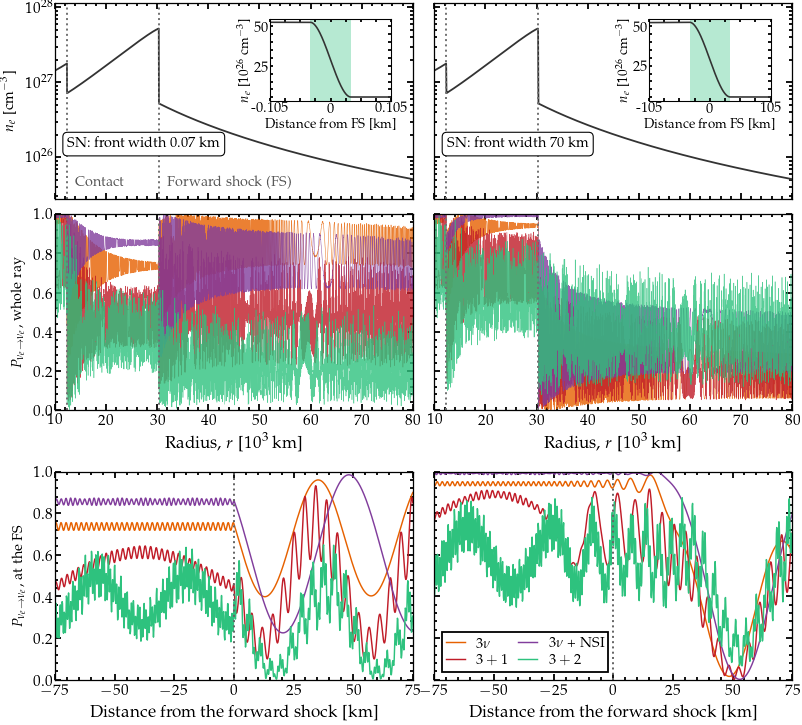

In [16]:
KM = gd.UNIT_KM
MEAN_NUCLEON = 0.5*(gd.MASS_PROTON + gd.MASS_NEUTRON)
R_CONTACT_KM, R_FORWARD_KM = 12348.0, 30323.0
R0_KM, R1_KM = 1.0e4, 8.0e4
L0, L1 = R0_KM*KM, R1_KM*KM
ENERGY = 15.0*gd.UNIT_MEV


def smoothstep(u):
    u = np.clip(np.asarray(u, dtype=float), 0.0, 1.0)
    return u*u*(3.0 - 2.0*u)


def rarefaction(r_km, r_shock_km):
    """ln f(x) = [0.28 - 0.69 ln(x_s/km)] [arcsin(1 - x/x_s)]^1.1  (Fogli et al. 2003)."""
    u = np.clip(1.0 - np.asarray(r_km, dtype=float)/r_shock_km, 0.0, 1.0)
    return np.exp((0.28 - 0.69*np.log(r_shock_km))*np.arcsin(u)**1.1)


def sn_shock_ne(width_frac, contact_jump=2.5, y_e=0.5):
    """Electron number density along the ray, for a front of the given width."""
    w_km = float(width_frac)*(R1_KM - R0_KM)

    def ne(l):
        r = np.asarray(l, dtype=float)/KM
        rho = 1.0e14*r**(-2.4)
        shocked = smoothstep((R_FORWARD_KM + 0.5*w_km - r)/w_km)
        factor = 1.0 + shocked*(10.0*rarefaction(r, R_FORWARD_KM) - 1.0)
        inside = smoothstep((R_CONTACT_KM + 0.5*w_km - r)/w_km)
        factor = factor*(1.0 + inside*(contact_jump - 1.0))
        out = rho*factor*gd.UNIT_G_PER_CM3/MEAN_NUCLEON*y_e
        return out[()] if np.ndim(out) == 0 else out

    return ne


def shock_breakpoints(width_frac):
    w_km = float(width_frac)*(R1_KM - R0_KM)
    edges = []
    for r in (R_CONTACT_KM, R_FORWARD_KM):
        edges += [(r - 0.5*w_km)*KM, (r + 0.5*w_km)*KM]
    return np.array([L0] + sorted(edges) + [L1])


WIDTHS = (1.0e-6, 1.0e-3)
OSC4 = dict(OSC); OSC4.update(STERILE4); OSC4.update(d14=0.0, d24=0.0)
OSC5_SHOCK = dict(OSC); OSC5_SHOCK.update(STERILE5)
OSC5_SHOCK.update(d14=0.0, d24=0.0, d15=0.0, d25=0.0, d35=0.0)
OSC2 = dict(sth=OSC['s12'], Dm2=OSC['D21'])
HALF_KM = 75.0
WIN = (R_FORWARD_KM - HALF_KM, R_FORWARD_KM + HALF_KM)
L_OSC_KM = 4.0*np.pi*ENERGY/OSC['D21']/KM
print('vacuum oscillation length at %g MeV: %.0f km; the ray spans %.0f of them'
      % (ENERGY/gd.UNIT_MEV, L_OSC_KM, (R1_KM - R0_KM)/L_OSC_KM))

Ls_full = np.linspace(1.02*L0, L1, 4000)
Ls_win = np.linspace(WIN[0]*KM, WIN[1]*KM, 1000)
COMMON = dict(L0=L0, nu_i=gd.NUE, nu_f=gd.NUE,
              density_is_of_number_of_electrons=True, rtol=RTOL_FIG, atol=ATOL_FIG)

SCEN = [
    (r'$3\nu$', ORANGE, lambda ne, bp, Ls: oscprob.osc_prob_matter_std_potential(
        3, ne, ENERGY, Ls, OSC, t_breakpoints=bp, **COMMON)),
    (r'$3+1$', RED, lambda ne, bp, Ls: oscprob.osc_prob_matter_std_potential(
        4, ne, ENERGY, Ls, OSC4, t_breakpoints=bp, **COMMON)),
    (r'$3\nu$ + NSI', PURPLE, lambda ne, bp, Ls: oscprob.osc_prob_matter_nsi(
        3, ne, ENERGY, Ls, OSC, EPS, t_breakpoints=bp, **COMMON)),
    (r'$3+2$', GREEN, lambda ne, bp, Ls: oscprob.osc_prob_matter_std_potential(
        5, ne, ENERGY, Ls, OSC5_SHOCK, t_breakpoints=bp, **COMMON)),
]

# Which engine answers?  Worth reporting, because the paper describes an adiabatic
# strategy at length and it is NOT what runs here: a baseline scan at one energy goes
# to the cumulative engine, and declared breakpoints make the hybrid stand aside in
# any case.  The whole ray is the Magnus ladder.
info = {}
quiet(oscprob.osc_prob_matter_std_potential, 3, sn_shock_ne(1e-3), ENERGY,
      Ls_full[:40], OSC, t_breakpoints=shock_breakpoints(1e-3),
      strategy_info=info, **COMMON)
print('engine answering this figure: %r (declined: %s)'
      % (info.get('engine'), [d[0] for d in (info.get('declined') or [])] or 'none'))

# Rows 1 and 2 share the full-ray axis and sit tight against each other; row 3 is a
# different axis entirely (a window at the front), so it gets its own block and its
# own gap.  A single hspace cannot do both.
fig = plt.figure(figsize=(WIDE, 6.3))
outer = fig.add_gridspec(2, 1, height_ratios=[2.25, 1.15], hspace=0.20)
gs_top = outer[0].subgridspec(2, 2, height_ratios=[1.15, 1.15], hspace=0.08,
                              wspace=0.06)
gs_bot = outer[1].subgridspec(1, 2, wspace=0.06)
axes = np.empty((3, 2), dtype=object)
for c in range(2):
    axes[0, c] = fig.add_subplot(gs_top[0, c])
    axes[1, c] = fig.add_subplot(gs_top[1, c], sharex=axes[0, c])
    axes[2, c] = fig.add_subplot(gs_bot[0, c])

for col, width in enumerate(WIDTHS):
    ne = sn_shock_ne(width)
    bp = shock_breakpoints(width)
    w_km = width*(R1_KM - R0_KM)
    wlab = ('%.2f' % w_km).rstrip('0').rstrip('.')
    top, mid, bot = axes[0, col], axes[1, col], axes[2, col]

    top.semilogy(Ls_full/KM/1.0e3, np.asarray(ne(Ls_full))/gd.UNIT_PER_CM3,
                 color=INK, lw=1.0)
    logy(top)
    # Limits from the data: they were pinned to the old MeV^3 scaling, which put the
    # cm^-3 curve thirty decades off the panel.
    ne_full = np.asarray(ne(Ls_full))/gd.UNIT_PER_CM3
    top.set_ylim(0.55*ne_full.min(), 2.2*ne_full.max())
    # Placed against the density rather than the panel top, so it sits over the flat
    # part of the profile instead of over its rise.
    top.text(0.035, 1.5e26, r'SN: front width %s km' % wlab, transform=
             top.get_yaxis_transform(), ha='left', va='center', fontsize=8.0,
             color='black', zorder=10,
             bbox=dict(boxstyle='round,pad=0.32', facecolor='white',
                       edgecolor='black', linewidth=0.6))

    # The front is 0.1% of the ray at most, so it cannot show on the axis above.  The
    # inset is the same window the bottom row uses, and is the only place the two
    # columns differ to the eye.
    # The inset spans a few front widths, not a fixed window: at 0.07 km a +/- 75 km
    # view shows a vertical line and no shaded band at all.
    half_in = max(1.5*w_km, 0.05)
    r_in = np.linspace(R_FORWARD_KM - half_in, R_FORWARD_KM + half_in, 600)
    ins = top.inset_axes([0.60, 0.50, 0.34, 0.42])
    # Scaled to 1e-5 MeV^3 so the axis needs no offset text, which collided with the
    # inset's own title at this size.
    ins.plot(r_in - R_FORWARD_KM,
             np.asarray(ne(r_in*KM))/gd.UNIT_PER_CM3/1.0e26, color=INK, lw=0.9)
    ins.axvspan(-0.5*w_km, 0.5*w_km, color=GREEN, alpha=0.35, lw=0, zorder=0)
    ins.set_xlim(-half_in, half_in)
    ins.set_xticks((-half_in, 0.0, half_in))
    ins.set_xticklabels([('%g' % v) for v in (-half_in, 0, half_in)])
    ins.yaxis.set_major_locator(plt.MaxNLocator(2))
    ins.tick_params(labelsize=8.0, pad=0.8, length=1.6)
    for side in ins.spines.values():
        side.set_linewidth(0.6)
    ins.set_xlabel(r'Distance from FS [km]', fontsize=7.4, labelpad=1.0)
    ins.set_ylabel(r'$n_e$ [$10^{26}$ cm$^{-3}$]', fontsize=7.4, labelpad=1.0)
    # A box on the parent marking where the inset was taken from, with corner
    # connectors.  At 0.07 km the box is a hairline, which is the honest width.
    lo, hi = top.get_ylim()
    rect, lines = top.indicate_inset(
        ((R_FORWARD_KM - half_in)/1.0e3, lo, 2.0*half_in/1.0e3, hi - lo),
        inset_ax=ins, edgecolor='0.45', linewidth=0.5, alpha=1.0)
    # Neither the marking box nor its connectors survive: the box spans the full height
    # of the panel, so at 70 km it reads as a shaded block standing over the shock.
    rect.set(visible=False)
    for ln in lines:
        ln.set(visible=False)

    for label, color, call in SCEN:
        def _run(call=call, ne=ne, bp=bp):
            return dict(full=np.asarray(quiet(call, ne, bp, Ls_full)).tolist(),
                        win=np.asarray(quiet(call, ne, bp, Ls_win)).tolist())
        _g = cached('shock_%s_%s' % (re.sub(r'\W+', '_', label).strip('_'),
                                     ('%g' % w_km).replace('.', 'p')),
                    ('shock', label, float(w_km), float(ENERGY),
                     [float(x) for x in Ls_full[::40]], [float(x) for x in Ls_win[::40]],
                     sorted(OSC.items()), sorted(STERILE4.items()),
                     sorted(STERILE5.items()), sorted((k, str(v)) for k, v in EPS.items())),
                    _run, what='one shock scenario at one front width')
        P_full, P_win = np.asarray(_g['full']), np.asarray(_g['win'])
        mid.plot(Ls_full/KM/1.0e3, P_full, color=color, lw=0.3, alpha=0.8)
        bot.plot(Ls_win/KM - R_FORWARD_KM, P_win, color=color, lw=0.8, label=label)
        print('  width %6.2f km  %-13s full P in %.3f-%.3f'
              % (w_km, label, P_full.min(), P_full.max()))

    for ax in (top, mid):
        ax.set_xlim(R0_KM/1.0e3, R1_KM/1.0e3)
        ax.xaxis.set_minor_locator(AutoMinorLocator(5))
        for r in (R_CONTACT_KM, R_FORWARD_KM):
            ax.axvline(r/1.0e3, color='0.45', lw=1.1, ls=':')
    top.tick_params(labelbottom=False)
    mid.set_ylim(0.0, 1.0); minor_y(mid, 5)
    mid.set_xlabel(r'Radius, $r$ [$10^3$ km]')

    bot.set_xlim(-HALF_KM, HALF_KM)
    bot.xaxis.set_minor_locator(AutoMinorLocator(5))
    bot.axvline(0.0, color='0.4', lw=1.1, ls=':')
    bot.set_ylim(0.0, 1.0); minor_y(bot, 5)
    bot.set_xlabel(r'Distance from the forward shock [km]')

    if col:
        for ax in (top, mid, bot):
            ax.tick_params(labelleft=False)

axes[0, 0].set_ylabel(r'$n_e$ [cm$^{-3}$]', fontsize=8.0)
axes[1, 0].set_ylabel(r'$P_{\nu_e \to \nu_e}$, whole ray', fontsize=8.0)
axes[2, 0].set_ylabel(r'$P_{\nu_e \to \nu_e}$, at the FS', fontsize=8.0)
axes[2, 1].legend(loc='lower left', handlelength=1.3, ncol=2, columnspacing=0.7,
                  labelspacing=0.2, fontsize=8.0)
# Named on both rows that show them: the bottom row speaks of "the forward shock"
# while the profile above carries two, which is a question a reader should not have
# to hold open.
for r, name in ((R_CONTACT_KM, 'Contact'), (R_FORWARD_KM, 'Forward shock (FS)')):
    axes[0, 0].annotate(name, xy=(r/1.0e3, 0.04),
                        xycoords=axes[0, 0].get_xaxis_transform(),
                        xytext=(4.5, 0), textcoords='offset points',
                        fontsize=8.0, color='0.35', ha='left', va='bottom')
save(fig, 'shock_probability.pdf')

### Figure 8 --- what an astrophysical flux arrives as

Decohered over the distance, so the observable is the flavor composition. Standard
oscillations make it independent of energy; the figure asks which new physics does not.

  astro_vacuum read from paper_figure_cache.json, unchanged configuration 5eaba3eb886b (measured 2026-08-31 on laptop-6)
  astro_liv read from paper_figure_cache.json, unchanged configuration 595e9b56752a (measured 2026-08-31 on laptop-6)
  astro_earth_nsi read from paper_figure_cache.json, unchanged configuration af0763e3f84f (measured 2026-08-31 on laptop-6)
  astro_pseudo_dirac read from paper_figure_cache.json, unchanged configuration 262166423b58 (measured 2026-09-01 on laptop-6)


  Standard 3\nu        survival at 1 TeV 0.548/0.407/0.386 -> at 10 PeV 0.548/0.407/0.386
  LIV                  survival at 1 TeV 0.548/0.407/0.386 -> at 10 PeV 0.894/0.502/0.454
  NSI through Earth    survival at 1 TeV 0.546/0.395/0.383 -> at 10 PeV 0.546/0.396/0.383
  3+1                  sterile takes 0.133-0.133 of the flux before renormalizing
  3+1                  survival at 1 TeV 0.454/0.321/0.386 -> at 10 PeV 0.454/0.321/0.386
  Pseudo-Dirac, \nu_2  sterile takes 0.193-0.193 of the flux before renormalizing
  Pseudo-Dirac, \nu_2  survival at 1 TeV 0.503/0.315/0.350 -> at 10 PeV 0.503/0.315/0.350


/tmp/ipykernel_11416/3216118111.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.3, w_pad=0.3, h_pad=0.4)


  wrote /home/mbustamante/Research/magnus/resources/paper/figs/astro_composition.pdf


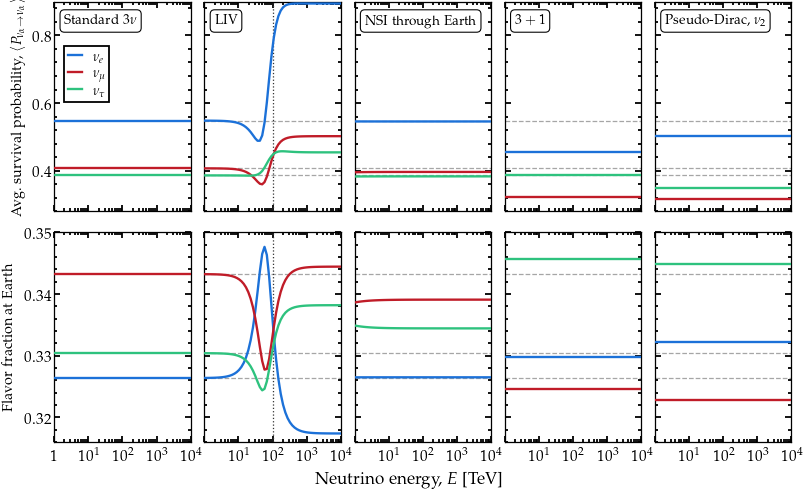

In [17]:
# ------------------------------------ Figure 8: what an astrophysical flux arrives as
# A neutrino from a distant source arrives decohered, so what is observable is not a
# probability curve but the flavor composition.  For standard oscillations that
# composition does not depend on energy at all; the point of the figure is which new
# physics makes it depend on energy, and where.
E_ASTRO = np.logspace(np.log10(1.0e3), np.log10(1.0e7), 60)*gd.UNIT_GEV   # 1 TeV to 10 PeV
PION_SOURCE = np.array([1.0/3.0, 2.0/3.0, 0.0])       # pion decay, before oscillating
COSTHZ_ASTRO = -1.0                                   # straight through the core
L_ASTRO = earth.distance_traveled_inside_earth(COSTHZ_ASTRO)*gd.CONV_KM_TO_INV_EV

# The LIV eigenvalue is fixed by where we want the new term to equal the vacuum one,
# rather than chosen for its size: at E_STAR the two are the same to within a percent.
N_LIV, E_STAR = 1, 100.0e3*gd.UNIT_GEV
B3_ASTRO = float(OSC['D31'])/(2.0*E_STAR**(N_LIV + 1))

HVA3 = np.asarray(vacuum_hamiltonian(3), dtype=complex)
HVA4 = np.asarray(vacuum_hamiltonian(4), dtype=complex)
def _astro_vac():
    return dict(p3=[avgprob.averaged_probabilities_constant_hamiltonian(HVA3/e).tolist()
                    for e in E_ASTRO],
                p4=[avgprob.averaged_probabilities_constant_hamiltonian(HVA4/e).tolist()
                    for e in E_ASTRO])


_av = cached('astro_vacuum',
             ('astro_vac', [float(e) for e in E_ASTRO], sorted(OSC.items()),
              sorted(STERILE4.items())), _astro_vac, what='the decohered vacuum matrices')
P_VAC3, P_VAC4 = np.asarray(_av['p3']), np.asarray(_av['p4'])


def liv_term(e):
    return np.asarray(hamiltonians.hamiltonian_3nu_liv(
        e, sxi12=OSC['s12'], sxi23=OSC['s23'], sxi13=OSC['s13'], dxiCP=0.0,
        b1=0.0, b2=0.0, b3=B3_ASTRO, Lambda=1.0, n_liv=N_LIV), dtype=complex)


P_LIV = np.asarray(cached(
    'astro_liv',
    ('astro_liv', [float(e) for e in E_ASTRO], N_LIV, float(B3_ASTRO), sorted(OSC.items())),
    lambda: [avgprob.averaged_probabilities_constant_hamiltonian(HVA3/e + liv_term(e)).tolist()
             for e in E_ASTRO], what='the decohered matrices with a Lorentz-violating term'))
# Through the Earth the flux is already decohered when it arrives, so the two legs
# compose as probability matrices rather than as amplitudes.
P_EARTH = np.asarray(cached(
    'astro_earth_nsi',
    ('astro_earth', [float(e) for e in E_ASTRO], COSTHZ_ASTRO, float(L_ASTRO),
     sorted(OSC.items()), sorted((k, str(v)) for k, v in EPS.items())),
    lambda: np.asarray(quiet(oscprob.osc_prob_3nu_earth_nsi, E_ASTRO, costhz=COSTHZ_ASTRO,
                             L=L_ASTRO, **OSC, **EPS, rtol=1e-6, atol=1e-8)).tolist(),
    what='the Earth leg with non-standard interactions'))
P_NSI = np.einsum('ij,ejk->eik', P_VAC3[0], P_EARTH)

# Pseudo-Dirac: each mass state may be two states split by a tiny delta m^2.  Pairing is
# chosen per state, and that is the whole of the physics here: pair all three and every
# active-active probability halves by the same factor, so the composition is untouched.
# Pair one, and the suppression is uneven and the composition moves.  We pair the second
# mass state alone.  At 100 Mpc a splitting of 1e-13 eV^2 leaves both members of the pair
# decohered from each other across the whole range drawn, so no averaged expression is
# being stretched: avgprob groups the spectrum itself, and finds six singletons.
L_SOURCE = 100.0*3.0857e19*gd.CONV_KM_TO_INV_EV        # 100 Mpc [eV^-1]
PD_PAIRS = {1: 1.0e-13}
U_PMNS = np.asarray(hamiltonians.pmns_mixing_matrix(
    OSC['s12'], OSC['s23'], OSC['s13'], OSC['dCP']), dtype=complex)
M2_PMNS = np.array([0.0, float(OSC['D21']), float(OSC['D31'])])


def _astro_pd():
    out = []
    for e in E_ASTRO:
        H = hamiltonians.hamiltonian_pseudo_dirac_vacuum(e, U_PMNS, M2_PMNS, PD_PAIRS)
        out.append(avgprob.averaged_probabilities_constant_hamiltonian(
            np.asarray(H, dtype=complex), baseline=L_SOURCE).tolist())
    return out


P_PD = np.asarray(cached(
    'astro_pseudo_dirac',
    ('astro_pd', [float(e) for e in E_ASTRO], sorted(PD_PAIRS.items()),
     float(L_SOURCE), sorted(OSC.items())),
    _astro_pd, what='the decohered matrices with one pseudo-Dirac pair'))

COMP_STD = np.einsum('a,eab->eb', PION_SOURCE, P_VAC3)
COMP_STD = COMP_STD/COMP_STD.sum(axis=1)[:, None]
CASES = [(r'Standard $3\nu$', P_VAC3, 3),
         (r'LIV',            P_LIV,  3),
         (r'NSI through Earth', P_NSI, 3),
         (r'$3+1$',           P_VAC4, 4),
         (r'Pseudo-Dirac, $\nu_2$', P_PD, 4)]
FCOL = {0: BLUE, 1: RED, 2: GREEN}
FLAB = {0: r'$\nu_e$', 1: r'$\nu_\mu$', 2: r'$\nu_\tau$'}

fig, axes = plt.subplots(2, 5, figsize=(WIDE, 4.1), sharex=True, sharey='row',
                         gridspec_kw=dict(hspace=0.10, wspace=0.10))
for col, (label, P, d) in enumerate(CASES):
    src = np.zeros(d); src[:3] = PION_SOURCE
    comp = np.einsum('a,eab->eb', src, P)[:, :3]
    # Renormalized to the active flavors: what a detector measures is the ratio among
    # the three it can see, and the sterile share is not observed rather than being a
    # fourth number to compare against.
    comp = comp/comp.sum(axis=1)[:, None]
    top, bot = axes[0, col], axes[1, col]
    for a in range(3):
        # The standard case under every panel, so that a small departure from it is
        # visible.  Three of the four cases are flat in energy; without the reference a
        # reader cannot see which of them sit at a different value.
        if col > 0:
            top.semilogx(E_ASTRO/gd.UNIT_TEV, P_VAC3[:, a, a], color='0.65', lw=0.7,
                         ls='--', zorder=1)
            bot.semilogx(E_ASTRO/gd.UNIT_TEV, COMP_STD[:, a], color='0.65', lw=0.7,
                         ls='--', zorder=1)
        top.semilogx(E_ASTRO/gd.UNIT_TEV, P[:, a, a], color=FCOL[a], lw=1.3, zorder=3,
                     label=FLAB[a] if col == 0 else None)
        bot.semilogx(E_ASTRO/gd.UNIT_TEV, comp[:, a], color=FCOL[a], lw=1.3, zorder=3)
    for ax in (top, bot):
        logx(ax); snug(ax, E_ASTRO/gd.UNIT_TEV)
    bot.xaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=12))
    unit_as_one(bot, which='x')
    corner(top, label, loc='upper left', x=0.075, fontsize=7.6)
    if d > 3:
        lost = 1.0 - np.einsum('a,eab->eb', src, P)[:, :3].sum(axis=1)
        print('  %-20s sterile takes %.3f-%.3f of the flux before renormalizing'
              % (label.replace('$', ''), lost.min(), lost.max()))
    print('  %-20s survival at 1 TeV %.3f/%.3f/%.3f -> at 10 PeV %.3f/%.3f/%.3f'
          % (label.replace('$', ''), P[0, 0, 0], P[0, 1, 1], P[0, 2, 2],
             P[-1, 0, 0], P[-1, 1, 1], P[-1, 2, 2]))
for _a in axes[1, :]:
    _a.tick_params(axis='x', which='major', pad=4.5)
fig.supxlabel(r'Neutrino energy, $E$ [TeV]',
              fontsize=plt.rcParams['axes.labelsize'], x=0.55, y=0.050)
axes[0, 0].set_ylabel(r'Avg.~survival probability, $\langle P_{\nu_\alpha \to \nu_\alpha}\rangle$',
                      fontsize=8.0)
axes[1, 0].set_ylabel(r'Flavor fraction at Earth', fontsize=8.0)
# Ranges chosen to show the differences rather than the distance from zero: every
# survival probability here lives above 0.30, and every flavor fraction between 0.31
# and 0.35.  The top is left to the data, so the LIV excursion is not clipped.
axes[0, 0].set_ylim(0.28, 0.90); minor_y(axes[0, 0], 5)
axes[1, 0].set_ylim(0.316, 0.35); minor_y(axes[1, 0], 5)
axes[0, 0].legend(loc='upper left', bbox_to_anchor=(0.02, 0.82), handlelength=1.1,
                  fontsize=7.4, ncol=1, labelspacing=0.25, borderpad=0.3)
axes[0, 1].axvline(E_STAR/gd.UNIT_TEV, color=INK, lw=0.7, ls=':')
axes[1, 1].axvline(E_STAR/gd.UNIT_TEV, color=INK, lw=0.7, ls=':')
fig.tight_layout(pad=0.3, w_pad=0.3, h_pad=0.4)
# Only the first column keeps its leftmost tick label; in the others it would sit
# against the previous panel's right spine.  This has to be done on the drawn text.
# sharex makes the five columns share one Ticker, so a formatter set on any of them
# governs all of them, and hiding a tick's label is undone by the next draw.
fig.canvas.draw()
for _ax in axes[1, 1:]:
    for _lb in _ax.get_xticklabels():
        if _lb.get_text() in ('$1$', '1'):
            _lb.set_visible(False)
save(fig, 'astro_composition.pdf')

## Figure 7 --- a smooth profile: reach, and the flavor ceiling

Four rows on one shared time axis, which spans three decades, so the cost of a flavor
count can be read against the others directly.

machine: Linux-7.0.0-28-generic-x86_64-with-glibc2.39 | interleaved control: 0.986


/tmp/ipykernel_11416/3659142302.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.3, h_pad=0.4)


  wrote /home/mbustamante/Research/magnus/resources/paper/figs/smooth_reach.pdf
  d=2 Magnus           best 7.92e-12, tightest 7.92e-12
  d=2 NuOscProbExact   best 2.56e-11, tightest 2.56e-11
  d=3 Magnus           best 2.93e-13, tightest 2.93e-13
  d=3 NuOscProbExact   best 2.52e-11, tightest 2.63e-11   <- rises
  d=4 Magnus           best 2.70e-11, tightest 2.70e-11
  d=4 NuOscProbExact   best 3.31e-11, tightest 3.31e-11
  d=5 Magnus           best 5.89e-11, tightest 5.89e-11


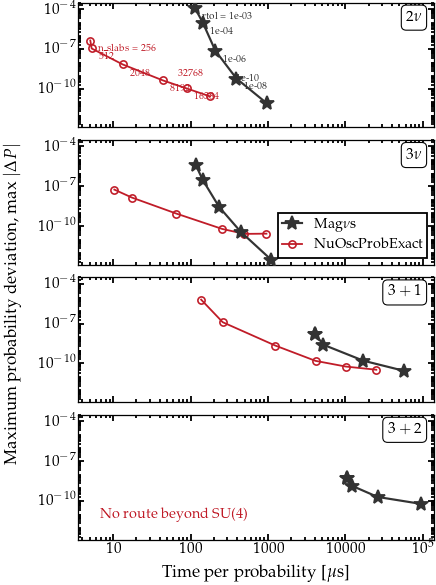

In [18]:
# ------------------------------------------------------------ smooth profile
BENCH = json.loads((HERE/'external_profile_benchmarks.json').read_text())
print('machine: %s | interleaved control: %s'
      % (BENCH['machine'], BENCH['control_ratio']))

fig, axes = plt.subplots(4, 1, figsize=(COL, 5.0), sharex=True,
                         gridspec_kw=dict(hspace=0.10))
for ax, case in zip(axes, BENCH['cases']):
    allt = []
    for series in case['series']:
        t = [p['us_per_probability'] for p in series['points']]
        e = [p['max_abs_error'] for p in series['points']]
        allt += t
        if series['name'] == 'Magnus':
            ax.loglog(t, e, '-*', color=INK, ms=8, lw=1.2, zorder=5, label=r'Mag$\nu$s')
        else:
            ax.loglog(t, e, '-o', color=RED, ms=4.0, mfc='none', mew=0.9, lw=1.0,
                      zorder=4, label='NuOscProbExact')
    if case is BENCH['cases'][0]:
        # The dial each code is turned by, written beside its markers.  The name appears
        # once per curve, on the topmost point; the rest carry the value alone.
        for series in case['series']:
            pts = series['points']
            dial = next((k for k in ('rtol', 'n_slabs', 'tolerance', 'num_prec')
                         if k in pts[0]), None)
            col = INK if series['name'] == 'Magnus' else RED
            top = max(range(len(pts)), key=lambda k: pts[k]['max_abs_error'])
            for k, pt in enumerate(pts):
                txt = ('%s = %s' % (dial, pt['label'])) if k == top and dial else pt['label']
                # Down and to the right of the marker.  Up and to the right put the
                # topmost label of each curve outside the axes, where it was clipped.
                # The last point of a series is its rightmost, so that one is set to
                # the left instead: to the right it ran past the axis.
                # The last point is a series' rightmost and usually its lowest, so its
                # label goes up and to the left: to the right it ran past the axis, and
                # below it landed on the reference floor.
                last = (k == len(pts) - 1)
                ax.annotate(txt, xy=(pt['us_per_probability'], pt['max_abs_error']),
                            xytext=(-4.0, 10.0) if last else (4.0, -6.5),
                            textcoords='offset points',
                            ha='right' if last else 'left',
                            va='bottom' if last else 'baseline',
                            fontsize=5.6, color=col, zorder=6,
                            annotation_clip=True)
    logx(ax); logy(ax)
    corner(ax, FLAVOR_LABEL[case['flavours']], loc='upper right', fontsize=8.5)
    if case['flavours'] == 5:
        ax.text(0.06, 0.20, 'No route beyond SU(4)', transform=ax.transAxes,
                ha='left', va='center', fontsize=8.0, color=RED, style='italic')

# One x-axis for all four: the panels differ by three decades in cost, so a shared
# range is what makes the flavor counts comparable at a glance.
ALL_T = [p['us_per_probability'] for c in BENCH['cases'] for s_ in c['series']
         for p in s_['points']]
ALL_E = [p['max_abs_error'] for c in BENCH['cases'] for s_ in c['series']
         for p in s_['points']]
for ax in axes:
    # Room past the extreme markers, so their labels have somewhere to sit.
    ax.set_xlim(0.7*min(ALL_T), 1.5*max(ALL_T))
    # A shared vertical range too: a reach that differs by flavor count is the point,
    # and per-panel autoscaling hides it.
    ax.set_ylim(min(ALL_E)/2.5, max(ALL_E)*2.5)
axes[1].legend(loc='lower right', handlelength=1.4)
axes[-1].set_xlabel(r'Time per probability [$\mu$s]')
fig.tight_layout(pad=0.3, h_pad=0.4)
# One y-label for the four panels, centred on the block rather than on any one of them.
fig.supylabel(r'Maximum probability deviation, max $|\Delta P|$',
              fontsize=plt.rcParams['axes.labelsize'], x=0.005)
save(fig, 'smooth_reach.pdf')
for case in BENCH['cases']:
    for s in case['series']:
        best = min(p['max_abs_error'] for p in s['points'])
        last = s['points'][-1]['max_abs_error']
        print('  d=%d %-16s best %.2e, tightest %.2e%s'
              % (case['flavours'], s['name'], best, last,
                 '   <- rises' if last > best*1.01 else ''))

## Figure 8 --- the same shock, as cost against accuracy

  width   0.07 km: Magnus 2.42e-09   NuOscProbExact 1.42e-09
  width  70.00 km: Magnus 9.60e-10   NuOscProbExact 5.60e-06


/tmp/ipykernel_11416/3531911277.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.3, h_pad=0.4)


  wrote /home/mbustamante/Research/magnus/resources/paper/figs/shock_speed_accuracy.pdf


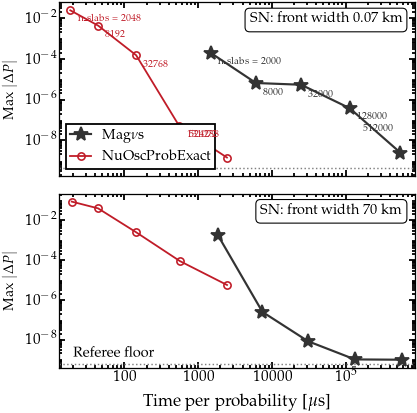

In [19]:
# ------------------------------------------------------------------ the shock
SHOCK = json.loads((HERE/'external_shock_benchmarks.json').read_text())
SPAN_KM = SHOCK['L1_km'] - SHOCK['L0_km']
fig, axes = plt.subplots(2, 1, figsize=(COL, 3.4), sharex=True,
                         gridspec_kw=dict(hspace=0.10))
for ax, case in zip(axes, SHOCK['cases']):
    width_km = case['width']*SPAN_KM
    allt = []
    for series in case['series']:
        t = [p['us_per_probability'] for p in series['points']]
        e = [p['max_abs_error'] for p in series['points']]
        allt += t
        if series['name'] == 'Magnus':
            ax.loglog(t, e, '-*', color=INK, ms=8, lw=1.2, zorder=5, label=r'Mag$\nu$s')
        else:
            ax.loglog(t, e, '-o', color=RED, ms=4.0, mfc='none', mew=0.9, lw=1.0,
                      zorder=4, label='NuOscProbExact')
    if case is SHOCK['cases'][0]:
        # Same convention as Fig. 7: the dial's value beside every marker, its name
        # written once per curve on the topmost point.
        for series in case['series']:
            pts = series['points']
            dial = next((k for k in ('rtol', 'n_slabs', 'tolerance', 'num_prec')
                         if k in pts[0]), None)
            col = INK if series['name'] == 'Magnus' else RED
            top = max(range(len(pts)), key=lambda k: pts[k]['max_abs_error'])
            for k, pt in enumerate(pts):
                txt = ('%s = %s' % (dial, pt['label'])) if k == top and dial else pt['label']
                # Down and to the right of the marker.  Up and to the right put the
                # topmost label of each curve outside the axes, where it was clipped.
                # The last point of a series is its rightmost, so that one is set to
                # the left instead: to the right it ran past the axis.
                # The last point is a series' rightmost and usually its lowest, so its
                # label goes up and to the left: to the right it ran past the axis, and
                # below it landed on the reference floor.
                last = (k == len(pts) - 1)
                ax.annotate(txt, xy=(pt['us_per_probability'], pt['max_abs_error']),
                            xytext=(-4.0, 10.0) if last else (4.0, -6.5),
                            textcoords='offset points',
                            ha='right' if last else 'left',
                            va='bottom' if last else 'baseline',
                            fontsize=5.6, color=col, zorder=6,
                            annotation_clip=True)
    ax.axhline(case['reference_unitarity'], color='0.5', ls=':', lw=0.8)
    logx(ax); logy(ax)
    corner(ax, 'SN: front width %s km'
           % ('%.2f' % width_km).rstrip('0').rstrip('.'), fontsize=8.0)
    ax.set_ylabel(r'Max $|\Delta P|$', fontsize=8.0)
    print('  width %6.2f km: Magnus %.2e   NuOscProbExact %.2e'
          % (width_km,
             min(p['max_abs_error'] for p in case['series'][0]['points']),
             min(p['max_abs_error'] for p in case['series'][1]['points'])))
ALL_TS = [p['us_per_probability'] for c in SHOCK['cases'] for s_ in c['series']
          for p in s_['points']]
for ax in axes:
    # A little room past the extreme markers, which otherwise sit on the spines and
    # leave their labels nowhere to go.
    ax.set_xlim(0.7*min(ALL_TS), 1.5*max(ALL_TS))
axes[0].legend(loc='lower left', handlelength=1.4)
stamp(axes[1], 'Referee floor', x=0.04, y=0.04, fontsize=8.0)
axes[-1].set_xlabel(r'Time per probability [$\mu$s]')
fig.tight_layout(pad=0.3, h_pad=0.4)
save(fig, 'shock_speed_accuracy.pdf')

## Figure 9 --- six codes through the Earth

**The matter potential is matched first**, and matching it does not buy a curve that falls
forever. The cell after the figure shows why.

  wrote /home/mbustamante/Research/magnus/resources/paper/figs/speed_accuracy_combined.pdf


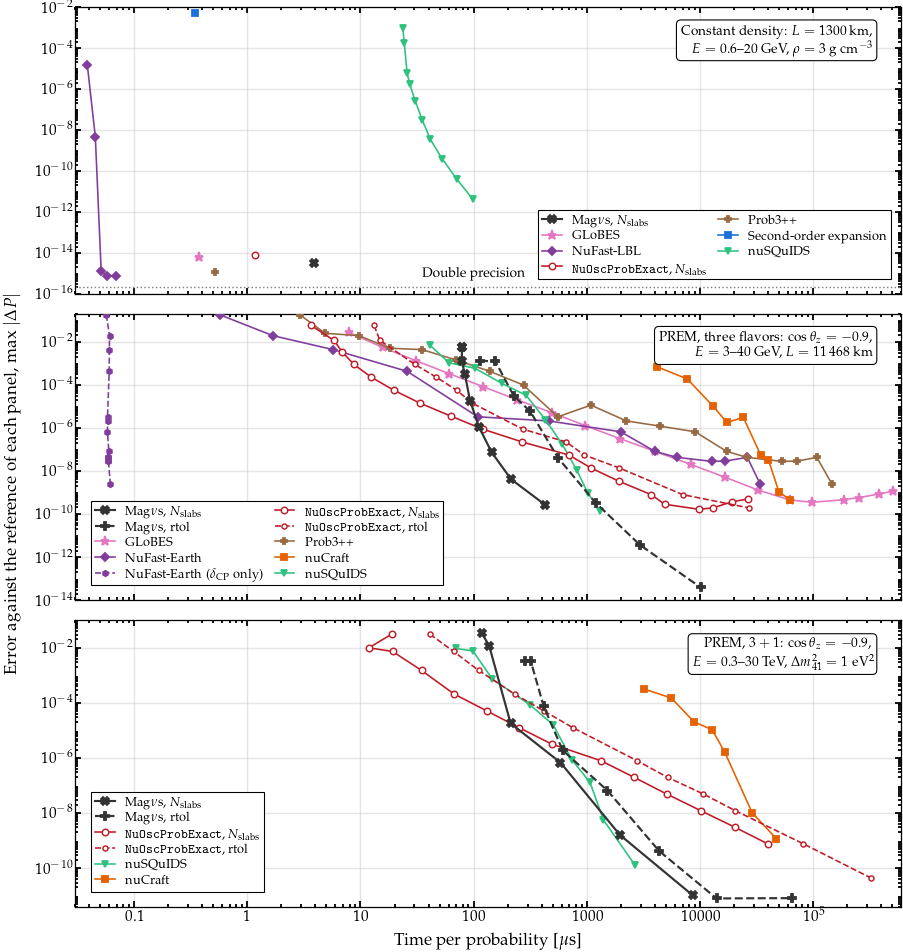

In [20]:
# ------------------------------------------------ three speed-accuracy planes
# Nothing here is measured at build time.  The external series are frozen in the
# repository, and so is Mag(nu)s' -- both produced by the benchmark harness in
# resources/benchmarks under its manifest's own protocols: ACCURACY untimed against
# each code's own 50-digit reference in that code's own conventions, and AMORTIZED,
# a 25-step delta_CP scan, for the time per grid point.  Measuring Mag(nu)s live
# here instead put minutes of stopwatch into continuous integration and, worse,
# timed it by a different rule than the codes it is drawn against.
CONST_PLANE = json.loads((HERE/'external_speed_accuracy_const.json').read_text())
EARTH_PLANE = json.loads((HERE/'external_earth_plane.json').read_text())
PREM = json.loads((HERE/'external_prem_speed_accuracy_new.json').read_text())

# Nothing is clipped.  An earlier draft clipped every point at the disagreement
# between each reference and an adaptive integration of the CONTINUOUS profile
# sharing none of its machinery, on the reading that nothing below that was resolved.
# The reading was wrong: that integration is itself double precision and stalls near
# 1e-11 for reasons of its own.  A second extrapolation at full precision sharing no
# slab count with the first is what settles it: at three flavors two disjoint 50-digit
# ladders agree to 1.1e-16, six orders beneath the stall.  The 3+1 referee is coarser --
# a single Richardson pair, not a ladder -- and a disjoint pair confirms it to 1.2e-12,
# which Magnus' tightest point there clears by a factor of six.  Clipping would have
# hidden four orders of real accuracy, and never bound an external point in any case:
# the smallest is 1.3e-10 at three flavors and 4.4e-11 at 3+1.

# One x range for all three panels, the union of what they reach.  It costs the outer
# two some width and buys the thing separate figures cannot show: 0.06 us for a cached
# NuFast-Earth and 6e4 us for nuCraft are the same distance apart in every panel.
XLIM_ALL = (3.0e-2, 6.0e5)

# Colour identifies a code across all three panels.  Mag(nu)s is the only curve drawn
# in ink, as it is throughout this paper: it is the code the paper is about, and
# nothing else on the plane is black except the axes and the legend frames.  It gets
# two curves for the same reason NuFast-Earth does -- one code, two dials that do not
# dominate one another -- so they share a colour and differ in marker and line.
STYLE = {'NuOscProbExact': ('-o', RED, 3.6),
         'NuOscProbExact (1 thread)': ('-o', RED, 3.6),
         'NuOscProbExact (tolerance)': ('--o', RED, 2.8),
         'NuOscProbExact (double-double)': ('-o', RED, 3.6),
         'NuOscProbExact (eigensolver)': (':h', RED, 3.4),
         'nuSQuIDS': ('-v', GREEN, 3.2), 'nuCraft': ('-s', ORANGE, 3.0),
         'NuFast-Earth': ('-D', PURPLE, 2.8),
         'NuFast-Earth (dCP only)': ('--h', PURPLE, 3.0),
         'NuFast-LBL': ('-D', PURPLE, 2.8),
         # GLoBES keeps the colour the companion paper gave it, so a reader holding
         # the two figures side by side tracks one code by one colour.
         'GLoBES': ('-*', '#e377c2', 5.2), 'Prob3++': ('-P', '#986a44', 3.6),
         'Second-order expansion': ('-s', BLUE, 3.0),
         'Magnus': ('-X', INK, 4.2), 'Magnus (tolerance)': ('--P', INK, 4.0)}

RELABEL = {'NuOscProbExact': r'{\tt NuOscProbExact}, $N_{\rm slabs}$',
           'NuOscProbExact (tolerance)': r'{\tt NuOscProbExact}, rtol',
           'NuOscProbExact (double-double)': r'{\tt NuOscProbExact}, $N_{\rm slabs}$',
           'NuOscProbExact (eigensolver)': r'{\tt NuOscProbExact}, eigensolver',
           'NuOscProbExact (1 thread)': r'{\tt NuOscProbExact}, 1 thread',
           'NuFast-Earth (dCP only)': r'NuFast-Earth ($\delta_{\rm CP}$ only)',
           'Magnus': r'Mag$\nu$s, $N_{\rm slabs}$',
           'Magnus (tolerance)': r'Mag$\nu$s, rtol'}


def by_dial(points):
    r"""Returns `points` in the order the DIAL sets, not the order of cost.

    Sorting by cost is right whenever the cost actually moves.  It is wrong for a
    series whose cost does not: NuFast-Earth's delta_CP curve spans 1.1x in cost
    against 15x to 7880x for everything else here, so ordering it by cost orders it
    by measurement noise and draws a U that is entirely an artifact.  A tolerance
    runs loose to tight and sorts descending; a slab or shell count sorts ascending.
    """
    try:
        values = [float(q['label']) for q in points]
    except (ValueError, KeyError):
        return list(points)
    return sorted(points, key=lambda q: float(q['label']),
                  reverse=min(values) < 1.0)


def magnus_first(series_list):
    r"""Mag(nu)s at the head of the list, everything else in file order.

    Drawing order is legend order, and this is the paper's own code: a reader
    looking for it should not have to search two columns of a legend box for it.
    Overplotting is unaffected -- the Mag(nu)s curves carry their own zorder.
    """
    mag = [s for s in series_list if s['name'].startswith('Magnus')]
    return mag + [s for s in series_list if not s['name'].startswith('Magnus')]


def draw_plane(ax, series_list, only=None):
    r"""Draws one speed-accuracy plane, and returns every time it plotted."""
    allt = []
    for series in magnus_first(series_list):
        if only is not None and series['name'] not in only:
            continue
        pts = by_dial(series['points'])
        marker, color, size = STYLE.get(series['name'], ('-o', '0.4', 3.2))
        kw = dict(ms=size, color=color, lw=0.9, zorder=4,
                  label=RELABEL.get(series['name'], series['name']))
        if series['name'].startswith('NuOscProbExact'):
            kw.update(mfc='white', mew=0.8, zorder=5)
        if series['name'].startswith('Magnus'):
            kw.update(zorder=6, lw=1.2)
        t = [p['us_per_probability'] for p in pts]
        allt += t
        ax.loglog(t, [p['max_abs_error'] for p in pts], marker, **kw)
    return allt


fig, axes = plt.subplots(3, 1, sharex=True, figsize=(WIDE, 7.4))

# --- constant density.  Only the fastest point at each accuracy is drawn: four of
# these codes have an INERT dial here, Mag(nu)s among them.  With one slab of constant
# density there is nothing to subdivide, so every setting returns the same answer and
# a sweep would be a stack of points at one height.
# Six codes, not eight: the file also holds NuFast-Earth, whose constant-density
# numbers repeat NuFast-LBL's, and a one-thread control for NuOscProbExact that lands
# on top of its own curve.  Both are measurements worth keeping and neither says
# anything a second line on this panel would add.
CONST_ONLY = ('GLoBES', 'NuFast-LBL', 'NuOscProbExact', 'Prob3++',
              'Second-order expansion', 'nuSQuIDS', 'Magnus')
for series in magnus_first(CONST_PLANE['series']):
    if series['name'] not in CONST_ONLY:
        continue
    pts = [q for q in series['points']
           if q.get('best_at_this_accuracy', True) and q['max_abs_error'] is not None]
    if not pts:
        continue
    pts.sort(key=lambda q: (-q['max_abs_error'], q['us_per_probability']))
    marker, color, size = STYLE.get(series['name'], ('-o', '0.4', 3.2))
    kw = dict(ms=size, color=color, lw=0.9, zorder=4,
              label=RELABEL.get(series['name'], series['name']))
    if series['name'].startswith('NuOscProbExact'):
        kw.update(mfc='white', mew=0.8, zorder=5)
    if series['name'].startswith('Magnus'):
        kw.update(zorder=6, lw=1.2)
    axes[0].loglog([q['us_per_probability'] for q in pts],
                   [q['max_abs_error'] for q in pts], marker, **kw)
axes[0].axhline(2.2e-16, color='0.5', ls=':', lw=0.8, zorder=1)
axes[0].set_ylim(1.0e-16, 1.0e-2)
stamp(axes[0], 'Double precision', x=0.42, y=0.045, fontsize=7.6)
corner(axes[0], 'Constant density:  $L = 1300$~km,\n'
       r'$E = 0.6$--$20$ GeV,  $\rho = 3$ g cm$^{-3}$', loc='upper right',
       fontsize=7.6)

# --- PREM, three flavors, and PREM 3+1.  The bottom panel is restricted to the codes
# that can express a sterile state, and to one of NuOscProbExact's two root
# strategies: they are both measured and frozen, but the curves coincide to the last
# bit and plotting both put two labels on one line.
draw_plane(axes[1], EARTH_PLANE['series'])
axes[1].set_ylim(1.0e-14, 2.0e-1)
corner(axes[1], r'PREM, three flavors:  $\cos\theta_z = -0.9$,' + '\n'
       r'$E = 3$--$40$ GeV,  $L = 11\,468$~km', loc='upper right', fontsize=7.6)

draw_plane(axes[2], PREM['sterile_3plus1']['series'],
           only={'NuOscProbExact (double-double)', 'NuOscProbExact (tolerance)',
                 'nuSQuIDS', 'nuCraft', 'Magnus', 'Magnus (tolerance)'})
axes[2].set_ylim(4.0e-12, 1.0e-1)
corner(axes[2], r'PREM, $3+1$:  $\cos\theta_z = -0.9$,' + '\n'
       r'$E = 0.3$--$30$ TeV,  $\Delta m_{41}^2 = 1$ eV$^2$', loc='upper right',
       fontsize=7.6)

for ax in axes:
    logx(ax); logy(ax)
    ax.set_xlim(*XLIM_ALL)
    # A vertical rule per decade of time, so a cost carries by eye from one panel to
    # the next -- which is the whole point of the shared axis.  Behind the data.
    ax.set_axisbelow(True)
    ax.grid(True, axis='both', which='major', color=GRID, lw=0.8, alpha=0.5, zorder=0)
# The top panel's points sit at the cheap, accurate corner, so its legend goes to the
# right; the Earth panels leave the lower left empty and fill the right, so theirs go
# to the left.  Both are the corners the curves do not reach.
for ax, loc, anchor, ncol in ((axes[0], 'lower right', (0.995, 0.03), 2),
                              (axes[1], 'lower left', (0.012, 0.03), 2),
                              (axes[2], 'lower left', (0.012, 0.03), 1)):
    leg = ax.legend(loc=loc, bbox_to_anchor=anchor, fontsize=7.2, ncol=ncol,
                    handlelength=1.5, labelspacing=0.22, columnspacing=0.9,
                    borderpad=0.3)
    leg.get_frame().set_linewidth(0.6)
axes[2].set_xlabel(r'Time per probability [$\mu$s]')
fig.supylabel(r'Error against the reference of each panel,  max $|\Delta P|$',
              fontsize=9.5, x=0.038)
fig.subplots_adjust(hspace=0.07, left=0.115, right=0.995, top=0.995, bottom=0.06)
save(fig, 'speed_accuracy_combined.pdf')

### Why the matched curve used to stop falling

An earlier version of this plane scored Mag$\nu$s against {\tt NuOscProbExact}'s
reference, matching the two charged-current potentials by handing Mag$\nu$s an electron
fraction of $0.5000948$ instead of $0.5$. That curve flattened near $1.6 \cdot 10^{-7}$
and no solver setting on either side reached beneath it. The floor was not a property of
either solver, and it was not, as we first read it, the potential match running out in
some general way. It has a single identifiable cause, and the cell below names it.

In [21]:
# Why matching V_CC through the electron fraction leaves a floor, and what the
# floor is worth.  This is a note about a measurement convention, not about the solver:
# every number the paper quotes for Magnus is measured against Magnus' OWN reference,
# where no such floor exists.
VCC_MATCH = 1.0001896489716906     # NuOscProbExact's V_CC over ours, at any density

print('On an Earth chord V_CC is NOT linear in Y_e.  oscprob.py derives the average')
print('nucleon mass from the composition -- r = (1-Y_e)/Y_e, layer by layer -- because')
print('a medium with Y_e = 0.4656 and r = 1 is matter that cannot exist.  So scaling')
print('Y_e scales the potential by very slightly more than the scale asked for:')
r_half = earth.neutron_to_proton_ratio_from_electron_fraction(0.5)
r_match = earth.neutron_to_proton_ratio_from_electron_fraction(0.5*VCC_MATCH)


def avg_nucleon(r):
    return (gd.MASS_PROTON + gd.MASS_NEUTRON*r)/(1.0 + r)


slip = avg_nucleon(r_half)/avg_nucleon(r_match) - 1.0
print('  r  goes %.10f -> %.10f' % (r_half, r_match))
print('  the average nucleon mass moves with it, and V_CC picks up a further %.3e' % slip)
print('  which is exactly the height the matched curve used to flatten at.')
print()
print('Matching a potential through the composition is therefore only ever good to')
print('that order.  The measurement this paper reports avoids the question entirely:')
print('the benchmark manifest asks for a per-code reference in each code\'s own')
print('conventions, so Magnus is scored at Y_e = 1/2 against a reference built with')
print('Magnus\' own constants, and the residual is the solver\'s alone.')

On an Earth chord V_CC is NOT linear in Y_e.  oscprob.py derives the average
nucleon mass from the composition -- r = (1-Y_e)/Y_e, layer by layer -- because
a medium with Y_e = 0.4656 and r = 1 is matter that cannot exist.  So scaling
Y_e scales the potential by very slightly more than the scale asked for:
  r  goes 1.0000000000 -> 0.9996207740
  the average nucleon mass moves with it, and V_CC picks up a further 1.306e-07
  which is exactly the height the matched curve used to flatten at.

Matching a potential through the composition is therefore only ever good to
that order.  The measurement this paper reports avoids the question entirely:
the benchmark manifest asks for a per-code reference in each code's own
conventions, so Magnus is scored at Y_e = 1/2 against a reference built with
Magnus' own constants, and the residual is the solver's alone.


## What was written

Thirteen PDFs, which is every figure in `resources/paper/main.tex`.

```bash
python notebooks/make_notebooks.py --only 28
```

In [22]:
for name in sorted(p.name for p in FIGDIR.glob('*.pdf')):
    print('  %-28s %8.1f kB' % (name, (FIGDIR/name).stat().st_size/1024.0))

  architecture.pdf                205.8 kB
  astro_composition.pdf           210.7 kB
  bsm.pdf                         195.3 kB
  earth_oscillogram.pdf          1015.1 kB
  phase_vs_profile.pdf            225.1 kB
  shock_probability.pdf           418.0 kB
  shock_speed_accuracy.pdf        171.7 kB
  smooth_reach.pdf                206.1 kB
  solar_averaged.pdf              204.7 kB
  solar_long_range.pdf            202.9 kB
  speed_accuracy_combined.pdf     246.5 kB
  strategies.pdf                  205.0 kB
  validation.pdf                  217.2 kB


---

**Previous:** [Animated scenes](27_magnus_animations.ipynb)  
**Next:** [Pseudo-Dirac neutrinos](29_magnus_pseudo_dirac.ipynb) --- tiny splittings, coherent blocks, and where the effect is invisible  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Implementation details](https://mbustama.github.io/Magnus/implementation_details.html) &middot; [All notebooks](.)